##### **notes for jun 22**


in bar plot: 
- make two bars for each variable --> one for just averaging and one for absolute value/average

in matrix: 
- same thing but two matrices 

### **imports**

In [1]:
import xarray as xr
import numpy as np
from pathlib import Path
import pandas as pd
from functools import partial

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import cmasher as cmr
from varname import argname # for checking variable name when plotting

### **loading in data and data prep**

##### **loading in .nc files**

loading in .nc files, extracting the integrated gradient dimension, averaging across result batches and long/lat to give variable importance values for each unique year combo and variable

In [2]:
# # getting directory for the result batches nc files 
# parent_dir = Path.cwd() / "climate_experiments" 

# # initializing dictionary for folder file counts to ensure each folder (differentiated as folder paths) has same number of folder items 
# folder_file_counts = {}

# # going thru directory to find any folders that start with result_batches (by the glob) & going thru it alphabetically (by the sorted)
# for run_folder in sorted(parent_dir.glob("result_batches*")):
#     # is_dir() to ensure that result_batches is actually a folder, not like a nc file or something idk 
#     if run_folder.is_dir():
#         # turning all the nc files in that folder into a list 
#         nc_files = list(run_folder.glob("*.nc"))
#         # if there are actually files in the folder
#         if nc_files: 
#             # count number of files in the folder and store that in the dictionary
#             folder_file_counts[run_folder] = len(nc_files)

# # error handling if all the folders are empty 
# if not folder_file_counts:
#     raise ValueError("no nc files in the folder!")


# # finding max number of file counts (should be 56/57) -- complete run length
# dynamic_expected = max(folder_file_counts.values())
# print(f"max is {dynamic_expected} files")


# # initializie list that will hold the arrays from every run 
# all_runs_data = []

# # going through each folder and looking at the files and the count of the files in the folder
# for run_folder, count in folder_file_counts.items():

#     # if the count of the files in the run folder does not equal 56/57 
#     if count != dynamic_expected:
#         print(f"skip{run_folder.name} bc only {count} files, expected {dynamic_expected}")
#         # keep going to the next folder and don't save the folder that doesn't have right amount of files 
#         continue
    
#     # saving the nc files in chrnological order (via sorted)
#     nc_files = sorted(list(run_folder.glob("*.nc")))
#     # opening the files in the folder
#         # concat_dim = yr_combo --> creates new dimension to stack all the arrays tg 
#         # combine = nested --> just stack in the order that files are alr in since alr sorted (computationally more efficient)
#     run_ds = xr.open_mfdataset(nc_files, concat_dim='yr_combo', combine='nested')
    
#     # extracting integrated gradient maps from nc file
#     run_data = run_ds['ig_heatmaps'].values
#         # run_data shape --> (56, 25, 144, 73, 7)
#     # converting integrated gradient values into only positive values (to measure magnitude of importance), averaging across sample dimension (axis 1)
#         # ig_heatmaps: (sample=25, lat=144, lon=73, feature=7)
    
#     run_mean_samples = np.nanmean((run_data), axis=1) # changed to not absolute value
#     # appending to list 
#     all_runs_data.append(run_mean_samples)


# # error handling if all folders do not have enough items 
# if not all_runs_data:
#     raise ValueError("none of the folders have enough nc files")

# # stacking all the averaged heatmaps 
# master_phi_matrix = np.stack(all_runs_data)
# print(master_phi_matrix.shape) # (11, 56, 144, 73, 6)



In [3]:
# print(np.max(master_phi_matrix[:, :, :, :, :]))

In [4]:
# def load_nc(do_mean):#, regional):

#     # A flag to take the mean or not (different types of variable importance, IG completeness property)
#     do_mean = do_mean.lower().strip()

#     # A flag to average across different var dims or not
#     #regional = regional.lower().strip()


#     # getting directory for the result batches nc files 
#     parent_dir = Path.cwd() / "climate_experiments" 

#     # initializing dictionary for folder file counts to ensure each folder (differentiated as folder paths) has same number of folder items 
#     folder_file_counts = {}

#     # going thru directory to find any folders that start with result_batches (by the glob) & going thru it alphabetically (by the sorted)
#     for run_folder in sorted(parent_dir.glob("result_batches*")):
#         # is_dir() to ensure that result_batches is actually a folder, not like a nc file or something idk 
#         if run_folder.is_dir():
#             # turning all the nc files in that folder into a list 
#             nc_files = list(run_folder.glob("*.nc"))
#             # if there are actually files in the folder
#             if nc_files: 
#                 # count number of files in the folder and store that in the dictionary
#                 folder_file_counts[run_folder] = len(nc_files)

#     # error handling if all the folders are empty 
#     if not folder_file_counts:
#         raise ValueError("no nc files in the folder!")


#     # finding max number of file counts (should be 56/57) -- complete run length
#     dynamic_expected = max(folder_file_counts.values())
#     print(f"max is {dynamic_expected} files")


#     # initializie list that will hold the arrays from every run 
#     all_runs_data = []

#     # going through each folder and looking at the files and the count of the files in the folder
#     for run_folder, count in folder_file_counts.items():

#         # if the count of the files in the run folder does not equal 56/57 
#         if count != dynamic_expected:
#             print(f"skip{run_folder.name} bc only {count} files, expected {dynamic_expected}")
#             # keep going to the next folder and don't save the folder that doesn't have right amount of files 
#             continue
        
#         # saving the nc files in chrnological order (via sorted)
#         nc_files = sorted(list(run_folder.glob("*.nc")))

        
#         # opening the files in the folder
#             # concat_dim = yr_combo --> creates new dimension to stack all the arrays tg 
#             # combine = nested --> just stack in the order that files are alr in since alr sorted (computationally more efficient)
#         run_ds = xr.open_mfdataset(nc_files, concat_dim='yr_combo', combine='nested')
        
#         # extracting integrated gradient maps from nc file
#         run_data = run_ds['ig_heatmaps'].values
#             # run_data shape --> (56, 25, 144, 73, 6)
        
        
#         # ----------------------- If do mean flag on ---------------------------------------
#         if do_mean == 'yes':
            
#             # averaging across sample dimension (axis 1)
#             #    ig_heatmaps: (sample=25, lat=144, lon=73, feature=6)
#             run_mean_samples = np.nanmean((run_data), axis=1, dtype=np.float64) 

            
#             # ADD ANOTHER OPTION FOR ABSOLUTE VALUE AND THEN MEAN FOR ANOTHER VAR IMPORTANCE PLOT


            
#             # appending to list 
#             all_runs_data.append(run_mean_samples)


#         # ----------------------- If do mean flag off ---------------------------------------
#         elif do_mean == 'no':

#             all_runs_data.append(run_data)
        

#         # --------------------- If flag entered improperly -----------------------------------
#         else:
#             raise ValueError("Enter yes or no for do_mean flag.")


#     # error handling if all folders do not have enough items 
#     if not all_runs_data:
#         raise ValueError("none of the folders have enough nc files")

#     # stacking all the averaged heatmaps 
#     return np.stack(all_runs_data)



# master_phi_matrix = load_nc(do_mean='yes')
# completeness_property_phi_matrix = load_nc(do_mean='no')

# print(master_phi_matrix.shape)
# print(completeness_property_phi_matrix.shape)

In [5]:
# def load_nc(do_mean, abs_val):#, regional):

#     # A flag to take the mean or not (different types of variable importance, IG completeness property)
#     do_mean = do_mean.lower().strip()

#     abs_val = abs_val.lower().strip()

#     # A flag to average across different var dims or not
#     #regional = regional.lower().strip()


#     # getting directory for the result batches nc files 
#     parent_dir = Path.cwd() / "climate_experiments" 

#     # initializing dictionary for folder file counts to ensure each folder (differentiated as folder paths) has same number of folder items 
#     folder_file_counts = {}

#     # going thru directory to find any folders that start with result_batches (by the glob) & going thru it alphabetically (by the sorted)
#     for run_folder in sorted(parent_dir.glob("result_batches*")):
#         # is_dir() to ensure that result_batches is actually a folder, not like a nc file or something idk 
#         if run_folder.is_dir():
#             # turning all the nc files in that folder into a list 
#             nc_files = list(run_folder.glob("*.nc"))
#             # if there are actually files in the folder
#             if nc_files: 
#                 # count number of files in the folder and store that in the dictionary
#                 folder_file_counts[run_folder] = len(nc_files)

#     # error handling if all the folders are empty 
#     if not folder_file_counts:
#         raise ValueError("no nc files in the folder!")


#     # finding max number of file counts (should be 56/57) -- complete run length
#     dynamic_expected = max(folder_file_counts.values())
#     print(f"max is {dynamic_expected} files")


#     # initializie list that will hold the arrays from every run 
#     all_runs_data = []

#     # going through each folder and looking at the files and the count of the files in the folder
#     for run_folder, count in folder_file_counts.items():

#         # if the count of the files in the run folder does not equal 56/57 
#         if count != dynamic_expected:
#             print(f"skip{run_folder.name} bc only {count} files, expected {dynamic_expected}")
#             # keep going to the next folder and don't save the folder that doesn't have right amount of files 
#             continue
        
#         # saving the nc files in chrnological order (via sorted)
#         nc_files = sorted(list(run_folder.glob("*.nc")))

        
#         # opening the files in the folder
#             # concat_dim = yr_combo --> creates new dimension to stack all the arrays tg 
#             # combine = nested --> just stack in the order that files are alr in since alr sorted (computationally more efficient)
#         run_ds = xr.open_mfdataset(nc_files, concat_dim='yr_combo', combine='nested')
        
#         # extracting integrated gradient maps from nc file
#         run_data = run_ds['ig_heatmaps'].values
#             # run_data shape --> (56, 25, 144, 73, 6)
        
        
#         # ----------------------- If do mean flag on ---------------------------------------
#         if do_mean == 'yes':

#             # ADD ANOTHER OPTION FOR ABSOLUTE VALUE AND THEN MEAN FOR ANOTHER VAR IMPORTANCE PLOT
#             # ----------------------- If abs val flag on ----------------------------------------
#             if abs_val == 'yes':

#                 run_mean_samples = np.nanmean((np.abs(run_data)), axis=1, dtype=np.float64)

#                 # appending to list 
#                 all_runs_data.append(run_mean_samples)


#             # ----------------------- If abs val flag off ---------------------------------------
#             elif abs_val == 'no':
                
#                 # averaging across sample dimension (axis 1)
#                 #    ig_heatmaps: (sample=25, lat=144, lon=73, feature=6)
#                 run_mean_samples = np.nanmean((run_data), axis=1, dtype=np.float64) 
                
#                 # appending to list 
#                 all_runs_data.append(run_mean_samples)


#              # --------------------- If flag entered improperly -----------------------------------
#             else:
#                 raise ValueError("Enter yes or no for abs_val flag.")
              


#         # ----------------------- If do mean flag off ---------------------------------------
#         elif do_mean == 'no':

#             all_runs_data.append(run_data)
        

#         # --------------------- If flag entered improperly -----------------------------------
#         else:
#             raise ValueError("Enter yes or no for each flag.")
        


#     # error handling if all folders do not have enough items 
#     if not all_runs_data:
#         raise ValueError("none of the folders have enough nc files")

#     # stacking all the averaged heatmaps 
#     return np.stack(all_runs_data)



# master_phi_matrix = load_nc(do_mean='yes', abs_val='no')
# abs_val_phi_matrix = load_nc(do_mean='yes', abs_val='yes')
# completeness_property_phi_matrix = load_nc(do_mean='no', abs_val='no')

# print(master_phi_matrix.shape)
# print(abs_val_phi_matrix.shape)
# print(completeness_property_phi_matrix.shape)

In [6]:
def load_nc_tryinglatlonrange(do_mean, abs_val, lat_range=None, lon_range=None):

    # A flag to take the mean or not (different types of variable importance, IG completeness property)
    do_mean = do_mean.lower().strip()

    # A flag to take abs val or not for different ways of interpreting variable importance
    abs_val = abs_val.lower().strip()


    # getting directory for the result batches nc files 
    parent_dir = Path.cwd() / "climate_experiments" 

    # initializing dictionary for folder file counts to ensure each folder (differentiated as folder paths) has same number of folder items 
    folder_file_counts = {}

    # going thru directory to find any folders that start with result_batches (by the glob) & going thru it alphabetically (by the sorted)
    for run_folder in sorted(parent_dir.glob("result_batches*")):
        # is_dir() to ensure that result_batches is actually a folder, not like a nc file or something idk 
        if run_folder.is_dir():
            # turning all the nc files in that folder into a list 
            nc_files = list(run_folder.glob("*.nc"))
            # if there are actually files in the folder
            if nc_files: 
                # count number of files in the folder and store that in the dictionary
                folder_file_counts[run_folder] = len(nc_files)

    # error handling if all the folders are empty 
    if not folder_file_counts:
        raise ValueError("no nc files in the folder!")


    # finding max number of file counts (should be 56/57) -- complete run length
    dynamic_expected = max(folder_file_counts.values())
    print(f"max is {dynamic_expected} files")


    # initializie list that will hold the arrays from every run 
    all_runs_data = []

    # going through each folder and looking at the files and the count of the files in the folder
    for run_folder, count in folder_file_counts.items():

        # if the count of the files in the run folder does not equal 56/57 
        if count != dynamic_expected:
            print(f"skip{run_folder.name} bc only {count} files, expected {dynamic_expected}")
            # keep going to the next folder and don't save the folder that doesn't have right amount of files 
            continue
        
        # saving the nc files in chrnological order (via sorted)
        nc_files = sorted(list(run_folder.glob("*.nc")))

        
        # opening the files in the folder
            # concat_dim = yr_combo --> creates new dimension to stack all the arrays tg 
            # combine = nested --> just stack in the order that files are alr in since alr sorted (computationally more efficient)
        
        # ----------------------- If no lat, lon given ---------------------------------------
        # with no lat/lon ranges:
        if not lat_range and not lon_range:

            run_ds = xr.open_mfdataset(nc_files, concat_dim='yr_combo', combine='nested')
        

        # ----------------------- If lat/lon range given ---------------------------------------
        elif lat_range and lon_range:

            def _preprocess(x, lon_bnds, lat_bnds):
                return x.sel(lon=slice(*lon_bnds), lat=slice(*lat_bnds))

            partial_func = partial(_preprocess, lon_bnds=lon_range, lat_bnds=lat_range)
            
            run_ds = xr.open_mfdataset(nc_files, concat_dim='yr_combo', preprocess=partial_func, combine='nested') 
 

        # extracting integrated gradient maps from nc file
        run_data = run_ds['ig_heatmaps'].values
            # run_data shape --> (56, 25, 144, 73, 6)
        
        
        # ----------------------- If do mean flag on ---------------------------------------
        if do_mean == 'yes':
                
                run_mean_samples = np.nanmean(np.abs(run_data), axis=1, dtype=np.float64) if abs_val == 'yes' else np.nanmean(run_data, axis=1, dtype=np.float64)

                # appending to list 
                all_runs_data.append(run_mean_samples)
              

        # ----------------------- If do mean flag off ---------------------------------------
        elif do_mean == 'no':

            all_runs_data.append(run_data)


        # --------------------- If flag entered improperly -----------------------------------
        else:
            raise ValueError("Enter yes or no for each flag.") 


    # error handling if all folders do not have enough items 
    if not all_runs_data:
        raise ValueError("none of the folders have enough nc files")

    # stacking all the averaged heatmaps 
    return np.stack(all_runs_data)

In [7]:
def load_nc(do_mean, abs_val, lat_range=None, lon_range=None):

    # A flag to take the mean or not (different types of variable importance, IG completeness property)
    do_mean = do_mean.lower().strip()

    # A flag to take abs val or not for different ways of interpreting variable importance
    abs_val = abs_val.lower().strip()


    # getting directory for the result batches nc files 
    parent_dir = Path.cwd() / "climate_experiments" 

    # initializing dictionary for folder file counts to ensure each folder (differentiated as folder paths) has same number of folder items 
    folder_file_counts = {}

    # going thru directory to find any folders that start with result_batches (by the glob) & going thru it alphabetically (by the sorted)
    for run_folder in sorted(parent_dir.glob("result_batches*")):
        # is_dir() to ensure that result_batches is actually a folder, not like a nc file or something idk 
        if run_folder.is_dir():
            # turning all the nc files in that folder into a list 
            nc_files = list(run_folder.glob("*.nc"))
            # if there are actually files in the folder
            if nc_files: 
                # count number of files in the folder and store that in the dictionary
                folder_file_counts[run_folder] = len(nc_files)

    # error handling if all the folders are empty 
    if not folder_file_counts:
        raise ValueError("no nc files in the folder!")


    # finding max number of file counts (should be 56/57) -- complete run length
    dynamic_expected = max(folder_file_counts.values())
    print(f"max is {dynamic_expected} files")


    # initializie list that will hold the arrays from every run 
    all_runs_data = []

    # going through each folder and looking at the files and the count of the files in the folder
    for run_folder, count in folder_file_counts.items():

        # if the count of the files in the run folder does not equal 56/57 
        if count != dynamic_expected:
            print(f"skip{run_folder.name} bc only {count} files, expected {dynamic_expected}")
            # keep going to the next folder and don't save the folder that doesn't have right amount of files 
            continue
        
        # saving the nc files in chrnological order (via sorted)
        nc_files = sorted(list(run_folder.glob("*.nc")))

        
        # opening the files in the folder
            # concat_dim = yr_combo --> creates new dimension to stack all the arrays tg 
            # combine = nested --> just stack in the order that files are alr in since alr sorted (computationally more efficient)
        
        # ----------------------- If no lat, lon given ---------------------------------------
        # with no lat/lon ranges:
        if not lat_range and not lon_range:

            run_ds = xr.open_mfdataset(nc_files, concat_dim='yr_combo', combine='nested')
        

        # ----------------------- If lat/lon range given ---------------------------------------
        elif lat_range and lon_range:

            def _preprocess(x, lon_bnds, lat_bnds):
                return x.sel(lon=slice(*lon_bnds), lat=slice(*lat_bnds))

            partial_func = partial(_preprocess, lon_bnds=lon_range, lat_bnds=lat_range)
            
            run_ds = xr.open_mfdataset(nc_files, concat_dim='yr_combo', preprocess=partial_func, combine='nested') 
 

        # extracting integrated gradient maps from nc file
        run_data = run_ds['ig_heatmaps'].values
            # run_data shape --> (56, 25, 144, 73, 6)
        
        
        # ----------------------- If do mean flag on ---------------------------------------
        if do_mean == 'yes':
                
                run_mean_samples = np.nanmean(np.abs(run_data), axis=1, dtype=np.float64) if abs_val == 'yes' else np.nanmean(run_data, axis=1, dtype=np.float64)

                # appending to list 
                all_runs_data.append(run_mean_samples)
              

        # ----------------------- If do mean flag off ---------------------------------------
        elif do_mean == 'no':

            all_runs_data.append(run_data)


        # --------------------- If flag entered improperly -----------------------------------
        else:
            raise ValueError("Enter yes or no for each flag.") 


    # error handling if all folders do not have enough items 
    if not all_runs_data:
        raise ValueError("none of the folders have enough nc files")

    # stacking all the averaged heatmaps 
    return np.stack(all_runs_data)



master_phi_matrix = load_nc(do_mean='yes', abs_val='no')
abs_val_phi_matrix = load_nc(do_mean='yes', abs_val='yes')
completeness_property_phi_matrix = load_nc(do_mean='no', abs_val='no')
regional_phi_matrix = load_nc(do_mean='yes', abs_val='no', lat_range=(180,200), lon_range=(50,70)) # Can also toggle abs_val flag back on 


print(master_phi_matrix.shape)
print(abs_val_phi_matrix.shape)
print(completeness_property_phi_matrix.shape)
print(regional_phi_matrix.shape)

max is 56 files
max is 56 files
max is 56 files
max is 56 files
(15, 56, 144, 73, 6)
(15, 56, 144, 73, 6)
(15, 56, 25, 144, 73, 6)
(15, 56, 0, 20, 6)


In [8]:
x_axis_completeness = np.nansum(completeness_property_phi_matrix, axis=(3,4,5)).flatten()

In [9]:
x_axis_completeness.shape

(21000,)

#### **making a df for yr combos and scenarios**

need unique yr combos and scenarios split up in differentiating way for easy discernment in plotting code 

In [10]:
def yr_scen_combo_df():    
    # providing folder example that has correct number of items (56/57)
    sample_folder = Path.cwd() / "climate_experiments" / "result_batchessophiekim_1" 
    print(sample_folder)
    # gets all the .nc files in chronological order 
    nc_files = sorted(list(sample_folder.glob("*.nc")))

    # initializing list
    data = []


    # looping through the .nc files to extract relevant info
    for idx, filepath in enumerate(nc_files):
        # getting filename from .stem -- just gives 'res_ssp119_2015_2025' as filename
        filename = filepath.stem 
        # splitting so that _ splits each word into diff strings rather than one big one 
            # [res, ssp119, 2015, 2025]
        parts = filename.split('_')
        print(parts)
        print(filename)
        
        # extracting relevant info from the parts var
        scenario_id = parts[1]
        early_yr = int(parts[-2]) # second to last 
        late_yr = int(parts[-1]) # last 
        
        # compliling all the info tg 
        data.append({
            'combo_idx': idx,
            'scenario': scenario_id,
            'early': early_yr,
            'late': late_yr
        })


    metadata_df = pd.DataFrame(data)

    return metadata_df

metadata_df = yr_scen_combo_df()

c:\Users\student\Desktop\mamalakis_research\MamalakisResearch\climate_experiments\result_batchessophiekim_1
['res', 'ssp119', '2015', '2025']
res_ssp119_2015_2025
['res', 'ssp119', '2015', '2035']
res_ssp119_2015_2035
['res', 'ssp119', '2015', '2045']
res_ssp119_2015_2045
['res', 'ssp119', '2015', '2055']
res_ssp119_2015_2055
['res', 'ssp119', '2015', '2065']
res_ssp119_2015_2065
['res', 'ssp119', '2015', '2075']
res_ssp119_2015_2075
['res', 'ssp119', '2015', '2085']
res_ssp119_2015_2085
['res', 'ssp119', '2025', '2035']
res_ssp119_2025_2035
['res', 'ssp119', '2025', '2045']
res_ssp119_2025_2045
['res', 'ssp119', '2025', '2055']
res_ssp119_2025_2055
['res', 'ssp119', '2025', '2065']
res_ssp119_2025_2065
['res', 'ssp119', '2025', '2075']
res_ssp119_2025_2075
['res', 'ssp119', '2025', '2085']
res_ssp119_2025_2085
['res', 'ssp119', '2035', '2045']
res_ssp119_2035_2045
['res', 'ssp119', '2035', '2055']
res_ssp119_2035_2055
['res', 'ssp119', '2035', '2065']
res_ssp119_2035_2065
['res', 'ssp

In [11]:
metadata_df

,combo_idx,scenario,early,late
0,0,ssp119,2015,2025
1,1,ssp119,2015,2035
2,2,ssp119,2015,2045
3,3,ssp119,2015,2055
4,4,ssp119,2015,2065
5,5,ssp119,2015,2075
6,6,ssp119,2015,2085
7,7,ssp119,2025,2035
8,8,ssp119,2025,2045
9,9,ssp119,2025,2055


#### **defining variables**

for plotting purposes, to discern out the 6 layers in the array dimension

In [12]:
# explicitly defining variables (order has to be exact as the .nc files)
climate_variables = ["tas", "tasmax", "tasmin", "pr", "psl", "sfcWind"] # got order from the get_cnn_tensors file bc that is when X_data was prepped


# making dictionary so that legible var name appears in heatmaps
variable_dictionary = {
    "tas": "Mean Surface\nTemp",
    "tasmax": "Max Surface\nTemp",
    "tasmin": "Min Surface\nTemp",
    "pr": "Precipitation",
    "psl": "Sea Level\nPressure",
    "sfcWind": "Surface Wind\nSpeed"
}

# making new list 
    # making variables readable by replacing the original var for the value in variable dictionary via list comprehension
readable_variables = [variable_dictionary[var] for var in climate_variables]

print(readable_variables)

['Mean Surface\nTemp', 'Max Surface\nTemp', 'Min Surface\nTemp', 'Precipitation', 'Sea Level\nPressure', 'Surface Wind\nSpeed']


### **variable importance heatmaps**

all on one colorbar scale

In [15]:
def var_importance_heatmaps_single_colorbar(phi_matrix, metadata_df, var_names, scenario_id="ssp119", regional='off'):
    """
    phi_matrix: all the averaged heatmaps from the ig layer of nc files --> shape = (10, 56, 144, 73, 7)
    metadata_df: df of all the unique yr combos
    var_names: variable names 
    scenario_id: scenario
    """
    
    # extracting out each dimension's length
    num_runs = phi_matrix.shape[0] # number of batch runs
    num_combos = phi_matrix.shape[1] # number of unique yr combos
    num_lon = phi_matrix.shape[2] # longitude
    num_lat = phi_matrix.shape[3] # latitude
    num_vars = phi_matrix.shape[4] # number of variables
    
    # calculating the sum of absolute value of the averaged ig heatmaps
        # basically total importance/attention that the CNN assigned across all 7 vars, grid points, yr combo, model runs
    total_phi_sum = np.nansum(np.abs(phi_matrix))
    # divide the sum by the product of multiplying all the dimensions' lengths (aka the number of data points)
        # gives the avg of importance at a single point -- global average baseline
    cbar_bound = total_phi_sum / (num_runs * num_combos * num_vars * num_lon * num_lat)
    
    # final averaging for plotting --> averaging across all the batches and long/lat 
        # first dimension = number of result batches, second = year combos, third = long, fourth = lat, fifth = variables
        # leaving behind the yr combos and variables 
    mean_importance = np.nanmean(np.abs(phi_matrix), axis=(0, 2, 3))
    

    # sorting by variable importance values 
        # argsort gives index position
        # sort gives actual values
    sorted_indices = np.argsort(mean_importance, axis=1)
    sorted_values = np.sort(mean_importance, axis=1)
    
    # getting the importance rankings for most important, second most important, least important 
    rank_keys = ["Most Important", "Second Most Important", "Least Important"]
    rank_data = [
        (sorted_indices[:, -1], sorted_values[:, -1]), # most important (last)
        (sorted_indices[:, -2], sorted_values[:, -2]), # 2nd most important (2nd to last)
        (sorted_indices[:, 0],  sorted_values[:, 0])   # least important (first)
    ]
    
    # getting the unique yr combos
        # pulling out unique early yrs  and unique late yrs 
        # set with the | --> makes set with early and late yr combos and only the unique ones since set does not allow for duplicates
        # sorted --> keeps everything chrnological
    # all_years provides clean sorted integer list 
    all_years = sorted(list(set(metadata_df['early'].unique()) | set(metadata_df['late'].unique())))
    # list comprehension that gives nice formatting of starting yr and end yr for all yr values in all_years
    labels = [f"{int(y)}-{int(y)+9}" for y in all_years]
    


    # PLOTTING NOW
    # 1 row and 3 plots with specified fig size 
    fig, axes = plt.subplots(1, 3, figsize=(26, 11))
    

    # create axis on bottom for single global colorbar at bottom center
     # [left, bottom, width, height]
    cbar_ax = fig.add_axes([0.35, 0.06, 0.3, 0.025]) 
    
    # going through the rankings 
    for i, rank_title in enumerate(rank_keys):
        rank_indices, rank_values = rank_data[i]
        # setting axes index for correct data to be in the corresponding importance heatmap
        ax = axes[i]
        
        
        # cell label formatting --> variable name and then next line is the variable importance value in scientific notation rounded to 2 dec places
            # list comprehension
                # zip puts the rank index and rank value tg (rank index is what variable it is and rank value is the IG importance value)
                # var_names[idx] pulls the variable name that corresponds with the rank index and then val for rank value 
        combined_labels = [
            f"{var_names[idx]}\n{val:.2e}" 
            for idx, val in zip(rank_indices, rank_values)
        ]
        
        # attaching the IG importance values and formatted text labels above to the metadata
        df = metadata_df.copy()
        df['importance_val'] = rank_values  
        df['text_label'] = combined_labels  
        
        # pivot table to rows as early yrs and cols are late yrs 
        color_matrix = df.pivot_table(index='early', columns='late', values='importance_val', aggfunc='first')
        # reindexing to make matrix include every early and late yr combos
        color_matrix = color_matrix.reindex(index=all_years, columns=all_years)
        
        # doing same thing as above but with the text labels 
        text_matrix = df.pivot_table(index='early', columns='late', values='text_label', aggfunc='first')
        text_matrix = text_matrix.reindex(index=all_years, columns=all_years).fillna("")
        
        # masking bottom left triangle shape of matrix since just repeats
        mask = np.tril(np.ones_like(color_matrix, dtype=bool), k=0)
        

        sns.heatmap(
            color_matrix,
            mask=mask,
            cmap=cmr.get_sub_cmap('mako_r', 0, 0.8), # To slice out the black part of the colormap
            annot=text_matrix.values, 
            fmt="",                   
            square=True,
            linewidths=.5,
            vmin=0,           # colorbar min value 
            vmax=cbar_bound,  # colorbar max value
            ax=ax,
            annot_kws={"size": 8}, # shrinking text size in each cell so everything fits 
            cbar=(i == 0),        # only draw colorbar on very first loop iteration
            cbar_ax=cbar_ax if i == 0 else None,  # put colorbar in center (location specified from cbar_ax)
            cbar_kws={"orientation": "horizontal"} if i == 0 else None 
        )
        
        
        # x axis lables on top 
        ax.xaxis.tick_top()
        ax.xaxis.set_label_position('top')
        # rotate x axis labels so diagonal 
        ax.set_xticklabels(labels, rotation=45, ha='left', fontsize=10, fontweight='bold')
        # horizontal y axis labels 
        ax.set_yticklabels(labels, rotation=0, fontsize=10, fontweight='bold')
        

        ax.set_xlabel("Late 10-Year Period", fontsize=12, fontweight='bold', labelpad=12)
        ax.set_ylabel("Early 10-Year Period", fontsize=12, fontweight='bold')
        ax.set_title(rank_title, fontsize=16, fontweight='bold', pad=25)

    # colorbar formatting
    cbar_ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.2e'))  # making colorbar scientific notation 
    cbar_ax.tick_params(labelsize=11)
    for tick in cbar_ax.get_xticklabels():
        tick.set_fontweight('bold')
    cbar_ax.set_xlabel("Mean Integrated Gradients ($\phi$)", fontsize=13, fontweight='bold', labelpad=10)
        
    plt.suptitle(f"Ranked Feature Matrices: {scenario_id.upper()}", fontsize=22, fontweight='bold', y=1.02)
    
    # tight_layout rect leaves the bottom 12% of the figure empty so not overlapping colorbar at the bottom
    # plt.tight_layout(rect=[0, 0.12, 1, 1]) 
    #  ^ giving error

    plt.rcParams['figure.constrained_layout.use'] = True 


    plt.show()

#### **plotting var importance heatmaps for both scenarios with one colorbar**

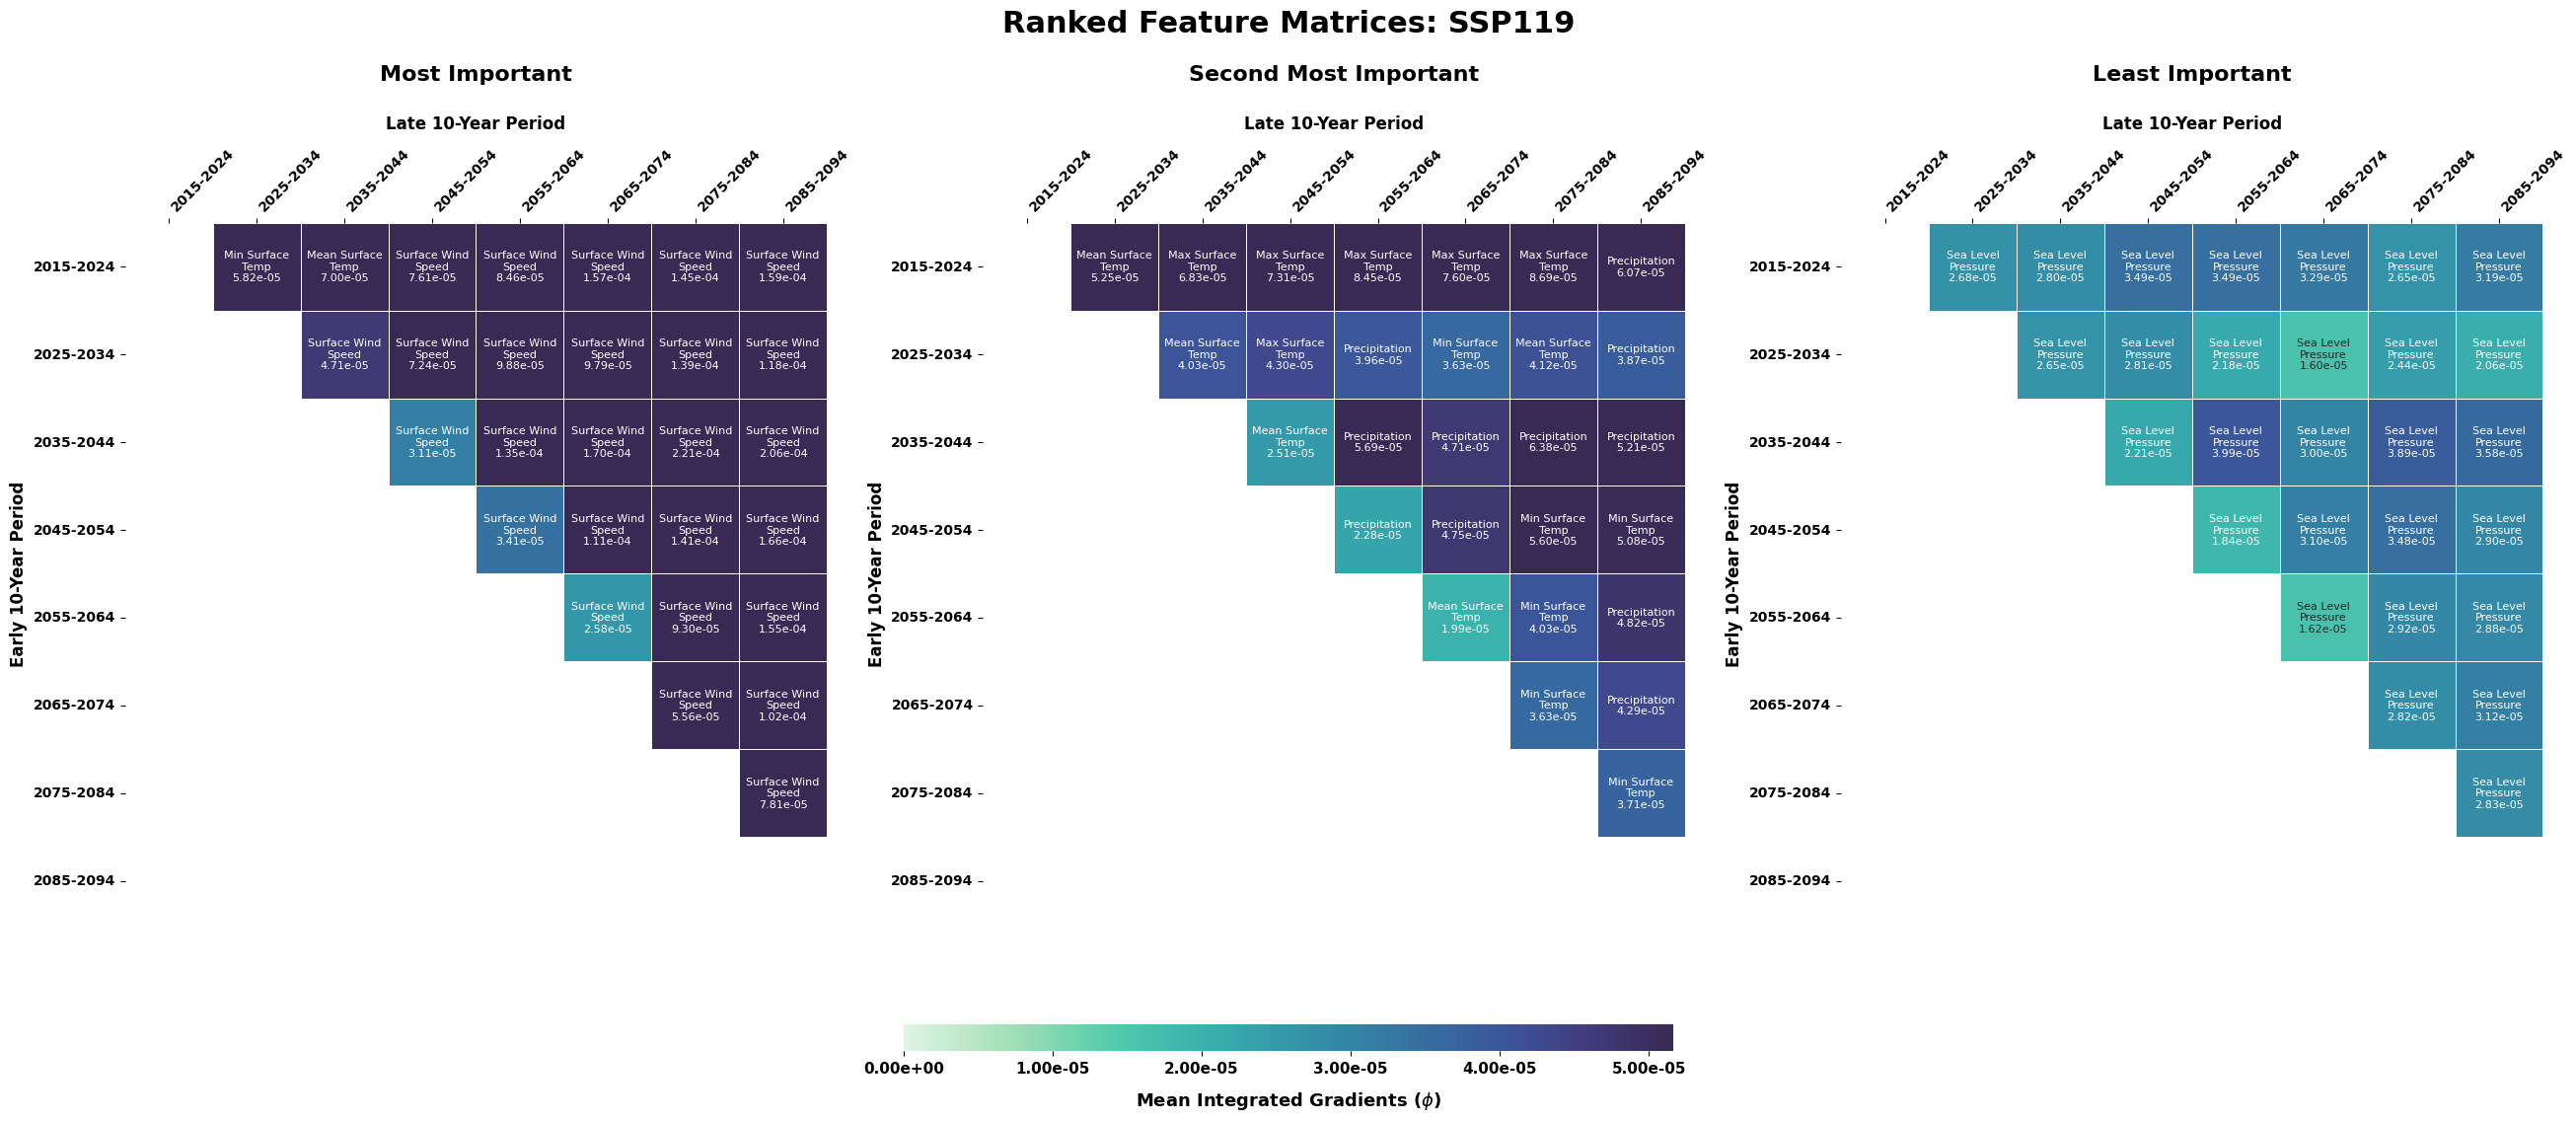

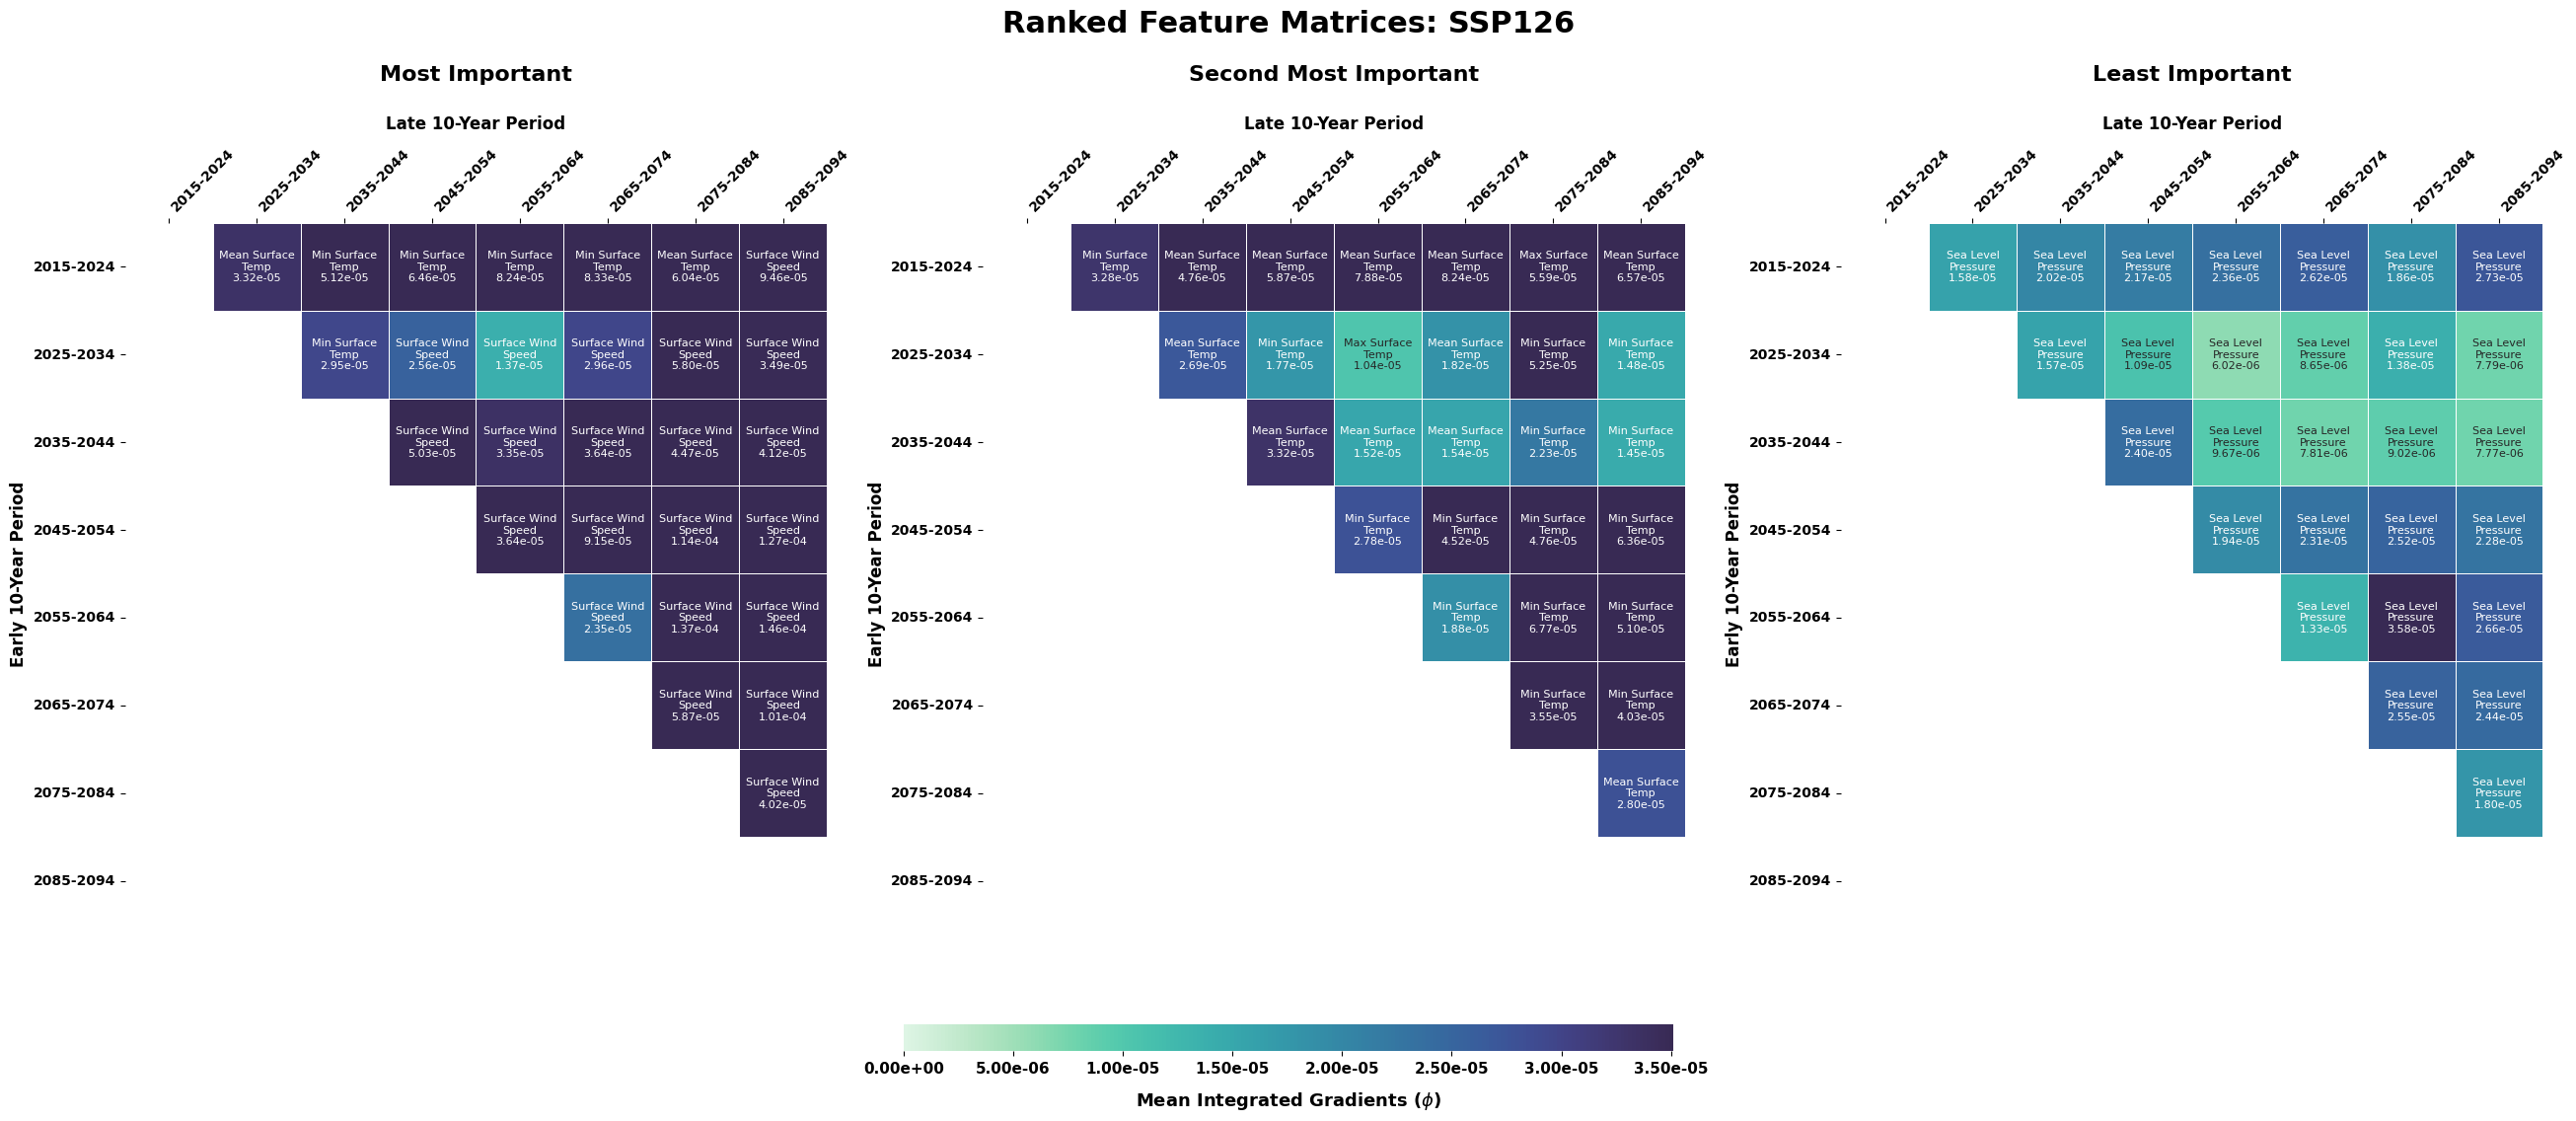

In [16]:
def plot_var_imp(phi_matrix, heatmap_sing_doub_func):
    # pulling unique scenario values
    unique_scenarios = metadata_df['scenario'].unique()

    for current_scenario in unique_scenarios:
        # filter metadata df for that one scenario 
        temp_df = metadata_df[metadata_df['scenario'] == current_scenario].copy()
        
        # slice phi matrix calculated above with the yr combo index values that are for that one scenario 
        temp_matrix = phi_matrix[:, temp_df['combo_idx'].values, :, :, :]
        
        # plot
        heatmap_sing_doub_func(
            phi_matrix=temp_matrix, 
            metadata_df=temp_df, 
            var_names=readable_variables, 
            scenario_id=current_scenario 
        )


plot_var_imp(master_phi_matrix, var_importance_heatmaps_single_colorbar)

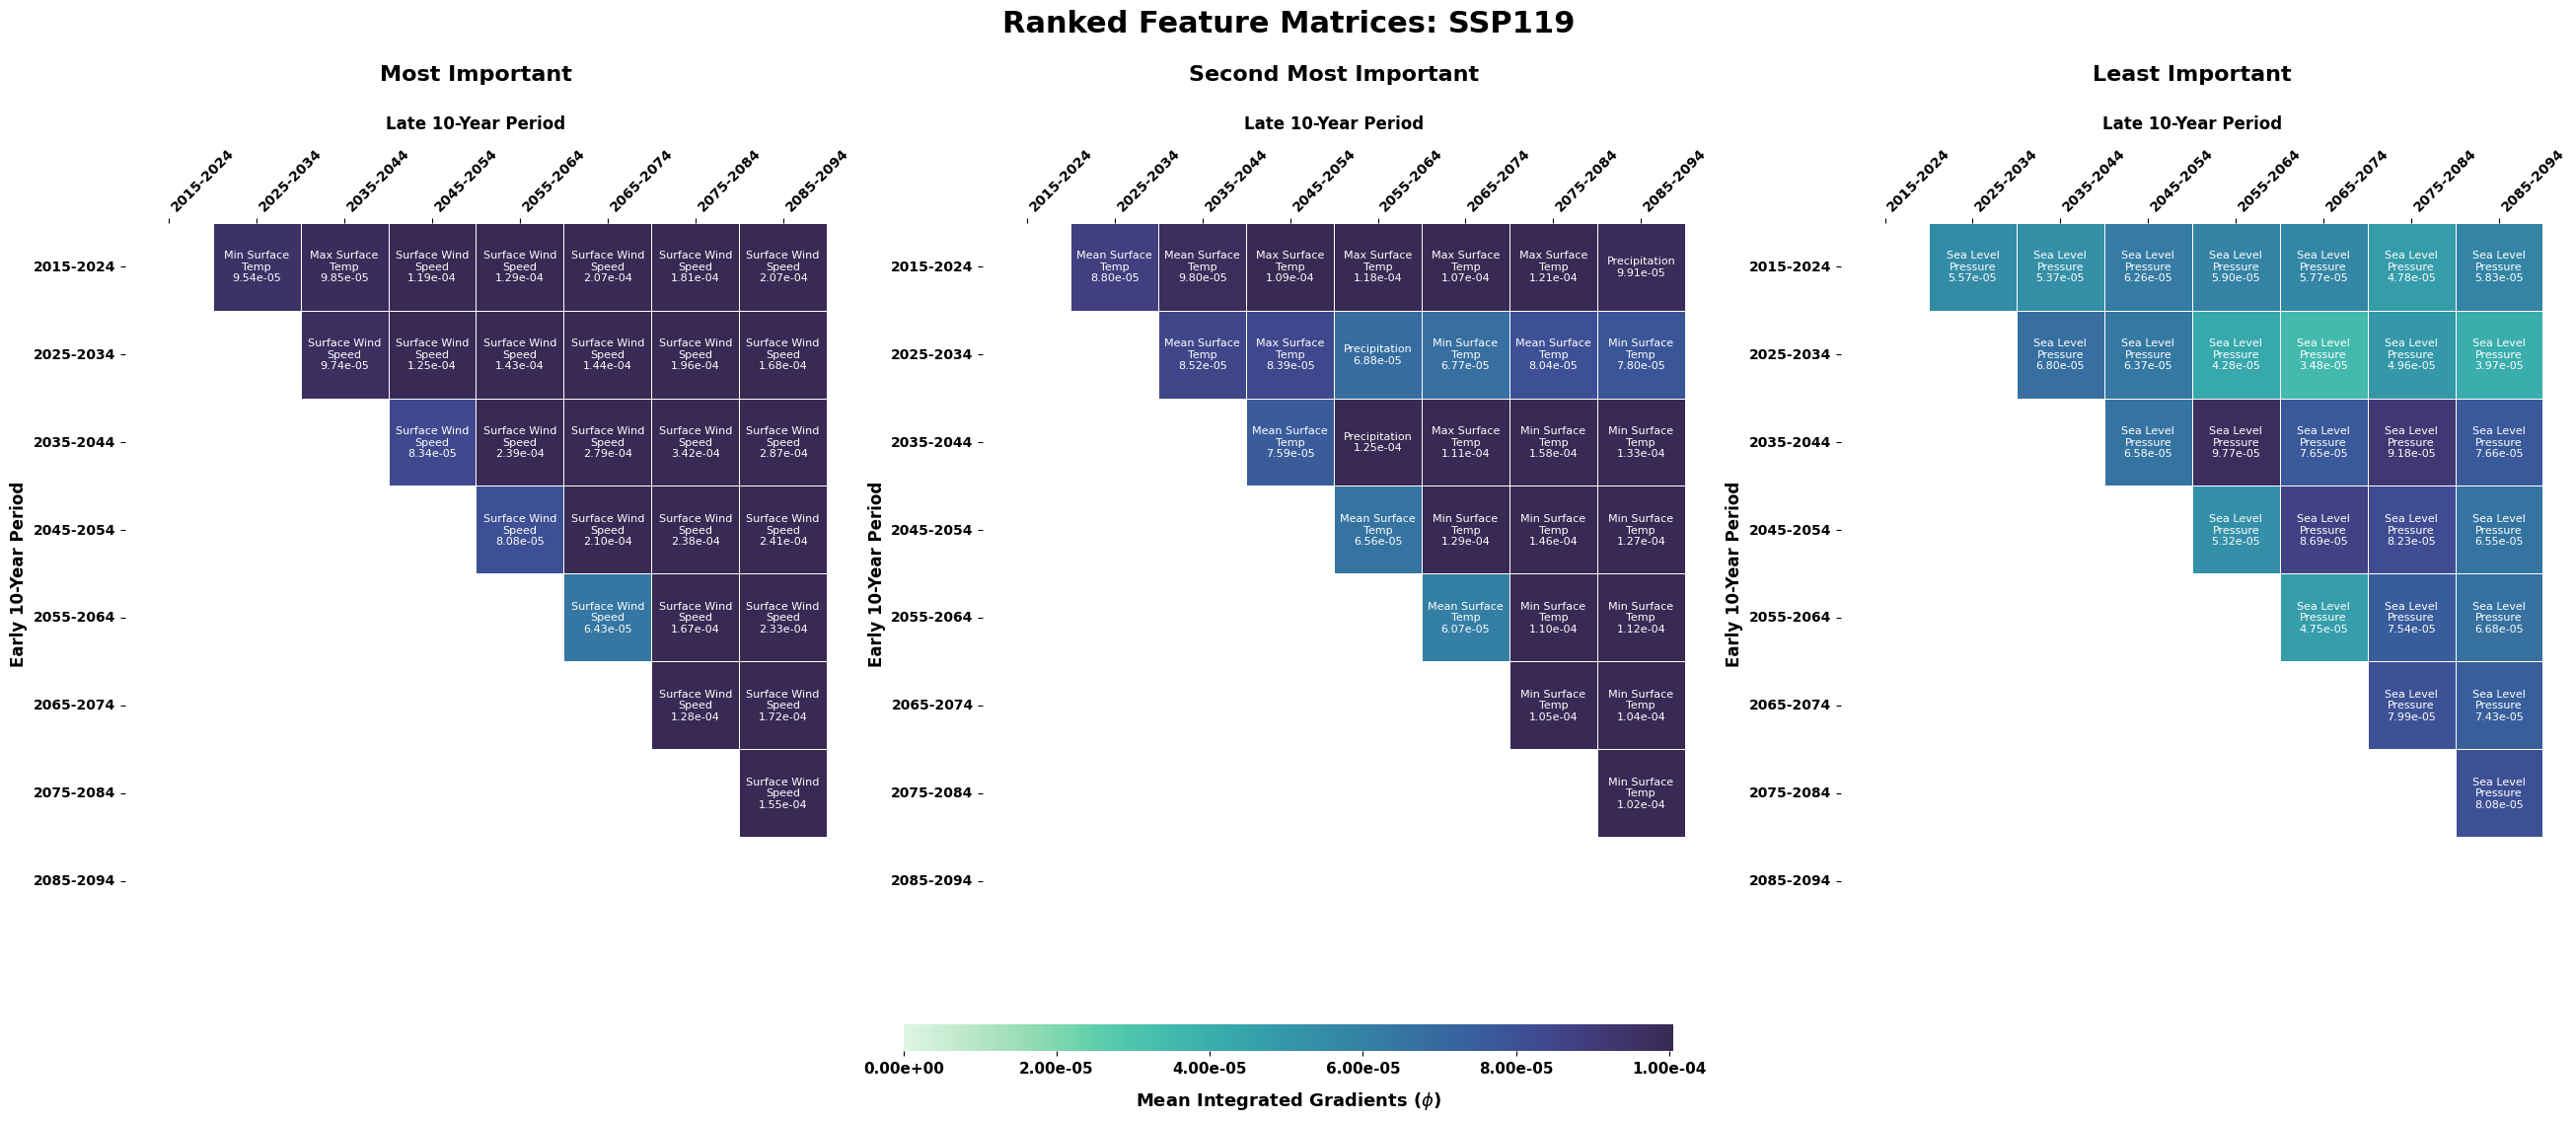

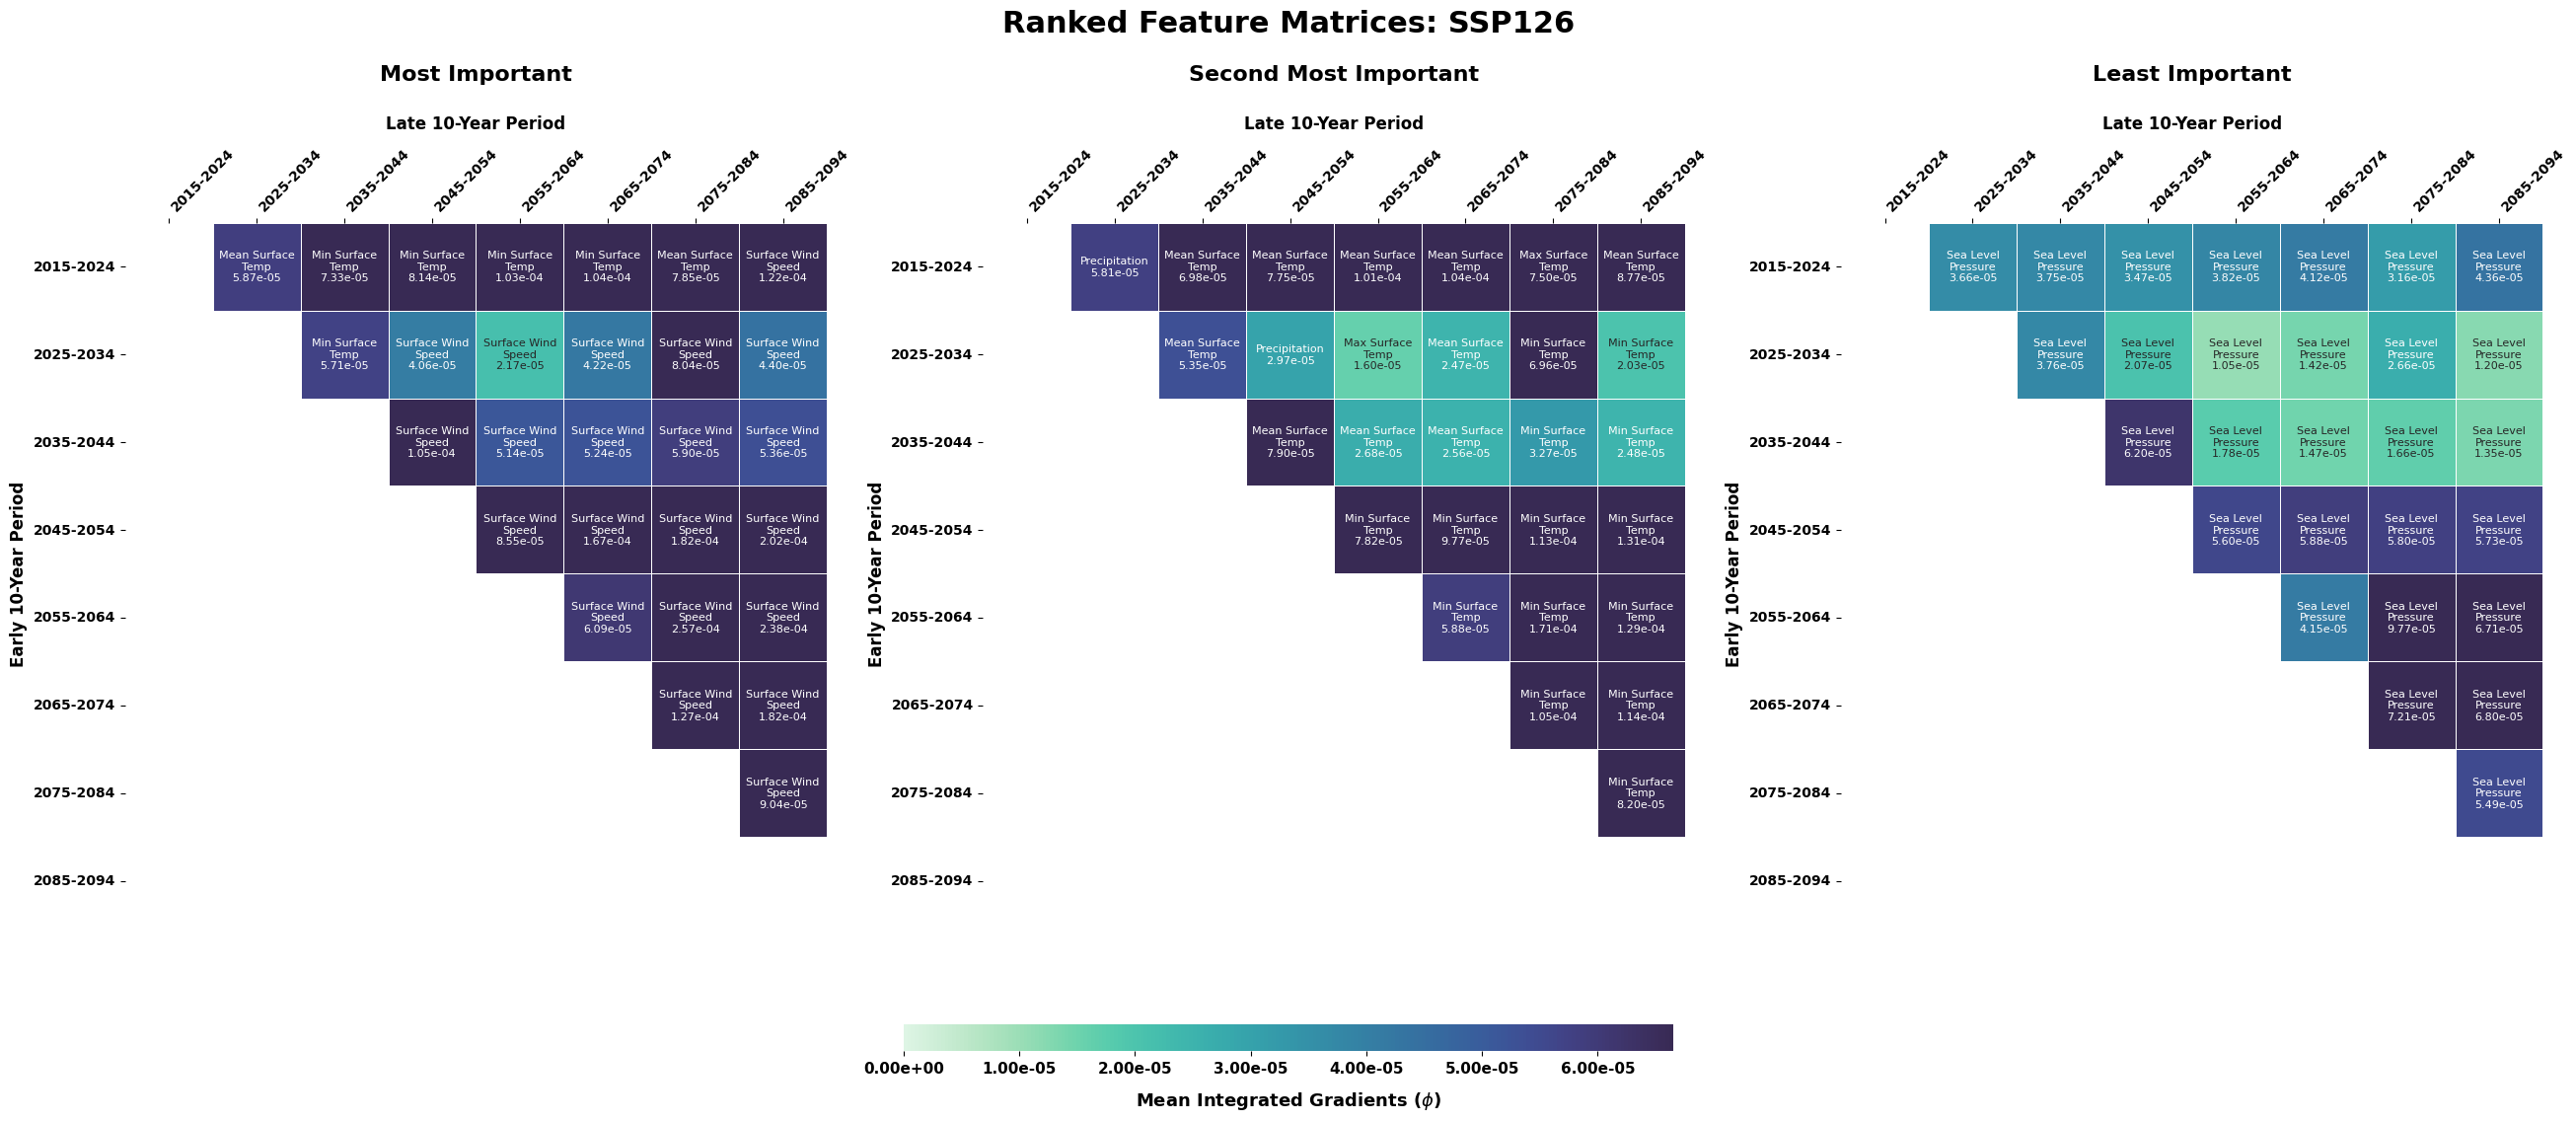

In [17]:
plot_var_imp(abs_val_phi_matrix, var_importance_heatmaps_single_colorbar)

In [18]:

def var_importance_heatmaps_three_colorbar(phi_matrix, metadata_df, var_names, scenario_id="ssp119"):
    """
    phi_matrix: all the averaged heatmaps from the ig layer of nc files --> shape = (10, 56, 144, 73, 7)
    metadata_df: df of all the unique yr combos
    var_names: variable names 
    scenario_id: scenario
    """
    
    # final averaging for plotting --> averaging across all the batches and long/lat 
        # first dimension = number of result batches, second = year combos, third = long, fourth = lat, fifth = variables
        # leaving behind the yr combos and variables 
    mean_importance = np.nanmean(np.abs(phi_matrix), axis=(0, 2, 3))
    
    # sorting by variable importance values 
        # argsort gives index position
        # sort gives actual values
    sorted_indices = np.argsort(mean_importance, axis=1)
    sorted_values = np.sort(mean_importance, axis=1)
    
     # getting the importance rankings for most important, second most important, least important 
    rank_keys = ["Most Important", "Second Most Important", "Least Important"]
    rank_data = [
        (sorted_indices[:, -1], sorted_values[:, -1]), # most important (last)
        (sorted_indices[:, -2], sorted_values[:, -2]), # 2nd most important (2nd to last)
        (sorted_indices[:, 0],  sorted_values[:, 0])   # least important (first)
    ]
    
    # getting the unique yr combos
        # pulling out unique early yrs  and unique late yrs 
        # set with the | --> makes set with early and late yr combos and only the unique ones since set does not allow for duplicates
        # sorted --> keeps everything chrnological
    # all_years provides clean sorted integer list 
    all_years = sorted(list(set(metadata_df['early'].unique()) | set(metadata_df['late'].unique())))
    # list comprehension that gives nice formatting of starting yr and end yr for all yr values in all_years
    labels = [f"{int(y)}-{int(y)+9}" for y in all_years]
    


   # PLOTTING NOW
    # 1 row and 3 plots with specified fig size 
    fig, axes = plt.subplots(1, 3, figsize=(26, 11))
    
    # going thru the rankings
    for i, rank_title in enumerate(rank_keys):
        rank_indices, rank_values = rank_data[i]
         # setting axes index for correct data to be in the corresponding importance heatmap
        ax = axes[i]
        
        # getting min and max values based on the min and maxes for that importance heatmap
        current_vmin = np.nanmin(rank_values)
        current_vmax = np.nanmax(rank_values)
        
         # cell label formatting --> variable name and then next line is the variable importance value in scientific notation rounded to 2 dec places
            # list comprehension
                # zip puts the rank index and rank value tg (rank index is what variable it is and rank value is the IG importance value)
                # var_names[idx] pulls the variable name that corresponds with the rank index and then val for rank value 
        combined_labels = [
            f"{var_names[idx]}\n{val:.2e}" 
            for idx, val in zip(rank_indices, rank_values)
        ]
        
        # attaching the IG importance values and formatted text labels above to the metadata
        df = metadata_df.copy()
        df['importance_val'] = rank_values  
        df['text_label'] = combined_labels  
        
        # pivot table to rows as early yrs and cols are late yrs 
        color_matrix = df.pivot_table(index='early', columns='late', values='importance_val', aggfunc='first')
        # reindexing to make matrix include every early and late yr combos
        color_matrix = color_matrix.reindex(index=all_years, columns=all_years)
        
        # doing same thing as above but with the text labels 
        text_matrix = df.pivot_table(index='early', columns='late', values='text_label', aggfunc='first')
        text_matrix = text_matrix.reindex(index=all_years, columns=all_years).fillna("")
        
        # lower triangle mask 
        mask = np.tril(np.ones_like(color_matrix, dtype=bool), k=0)
        
        sns.heatmap(
            color_matrix,
            mask=mask,
            cmap=cmr.get_sub_cmap('mako_r', 0, 0.8), # To slice out the black part of the colormap
            annot=text_matrix.values, 
            fmt="",                   
            square=True,
            linewidths=.5,
            vmin=current_vmin, # gives colorbar value of minimum value of that importance variable ranking 
            vmax=current_vmax, # same for min value of colorbar
            ax=ax,
            annot_kws={"size": 8}, # text size of cell text 
            cbar_kws={ # colorbar orientation and whatnot
                "orientation": "horizontal", 
                "pad": 0.12,                 
                "shrink": 0.85 
            } 
        )
        
        colorbar = ax.collections[0].colorbar # grabbing colorbar for that specific heatmap
        colorbar.ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.2e')) # scentific formatting 
        colorbar.ax.tick_params(labelsize=10)
        for tick in colorbar.ax.get_xticklabels():
            tick.set_fontweight('bold')
            
        colorbar.set_label("Mean IG ($\phi$)", fontsize=10, fontweight='bold', labelpad=5)
        
        ax.xaxis.tick_top()
        ax.xaxis.set_label_position('top')
        
        ax.set_xticklabels(labels, rotation=45, ha='left', fontsize=10, fontweight='bold')
        ax.set_yticklabels(labels, rotation=0, fontsize=10, fontweight='bold')
        
        ax.set_xlabel("Late 10-Year Period", fontsize=11, fontweight='bold', labelpad=12)
        ax.set_ylabel("Early 10-Year Period", fontsize=11, fontweight='bold')
        ax.set_title(rank_title, fontsize=15, fontweight='bold', pad=25)
        
    plt.suptitle(f"Ranked Feature Matrices: {scenario_id.upper()}", fontsize=20, fontweight='bold', y=1.02)
    
    plt.rcParams['figure.constrained_layout.use'] = True
    
    fig.get_layout_engine().set(w_pad= 2 / 72)

    plt.show()

#### **plotting var importance heatmaps for both scenarios with colorbar for each importance ranking**


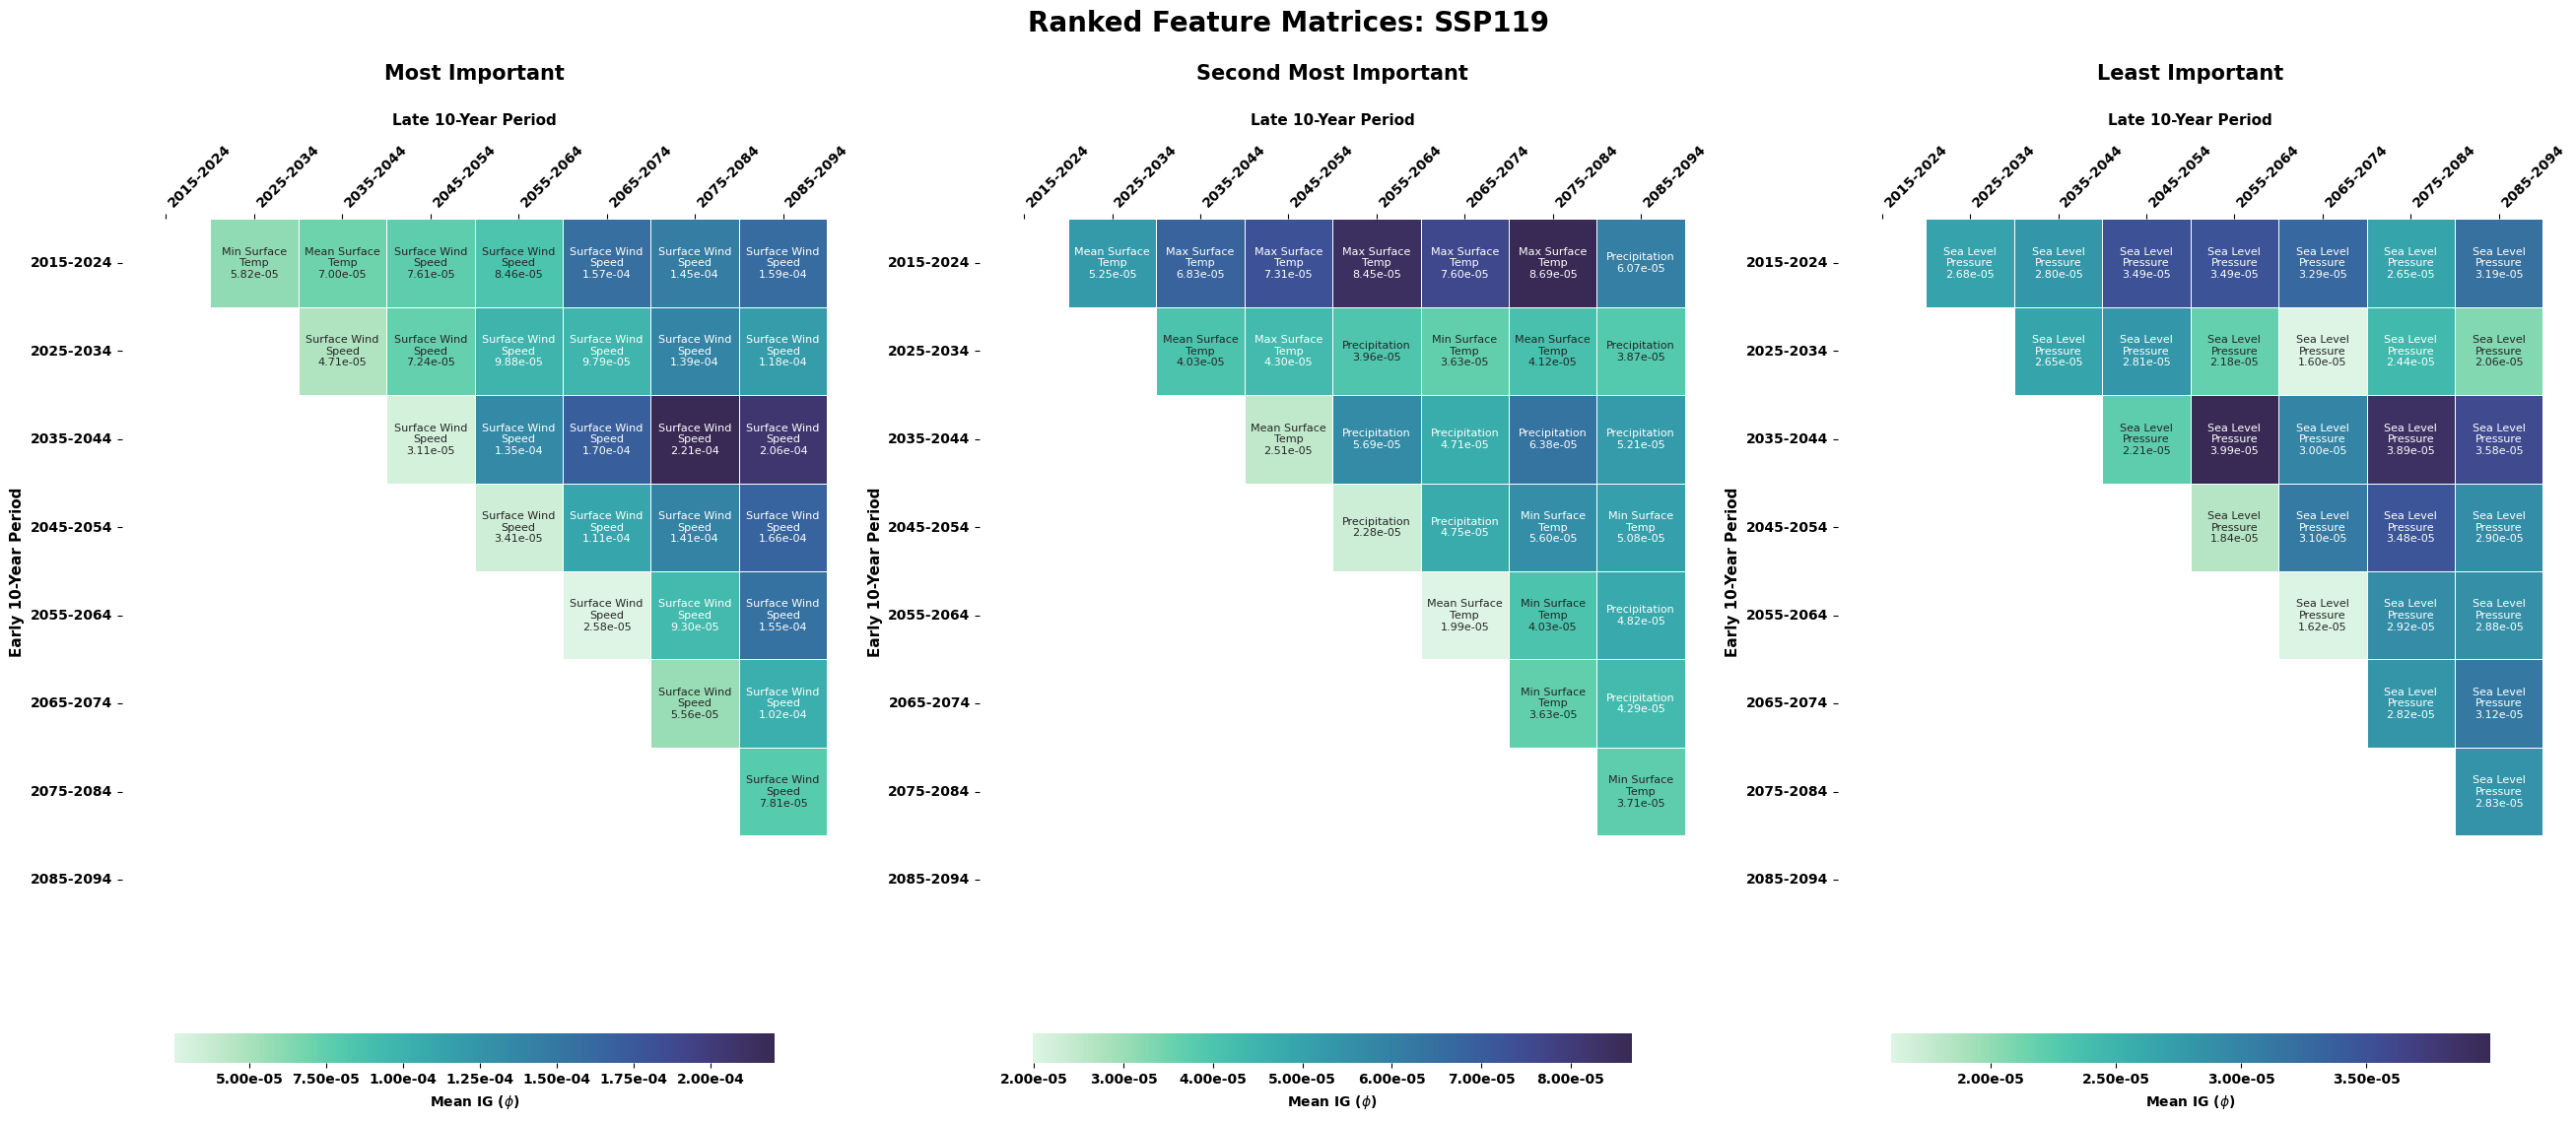

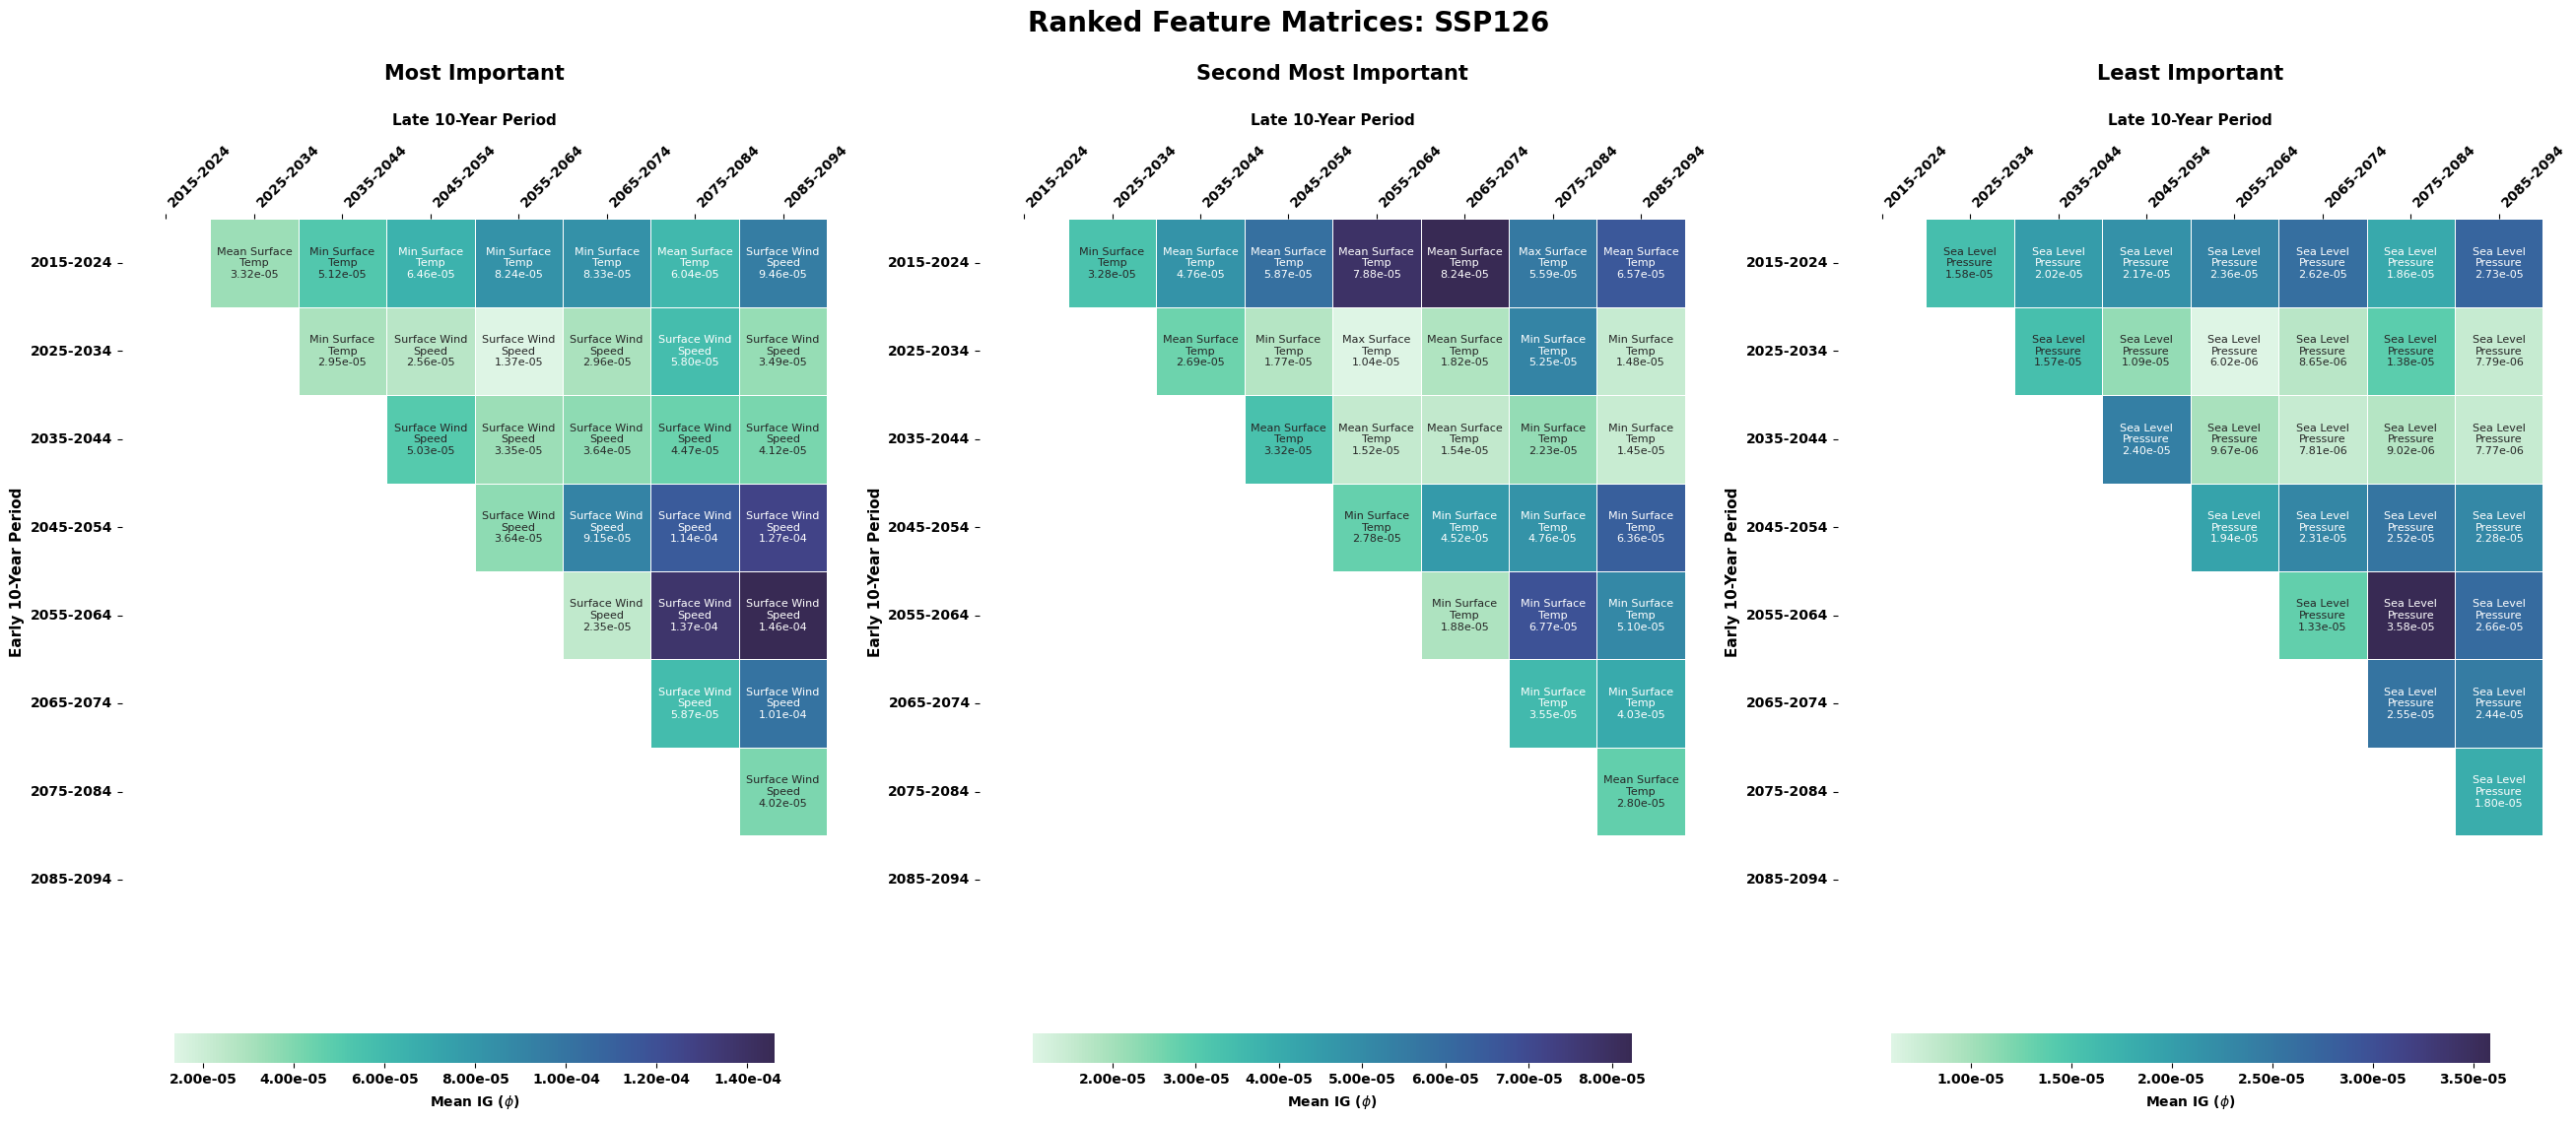

In [19]:
plot_var_imp(master_phi_matrix, var_importance_heatmaps_three_colorbar)

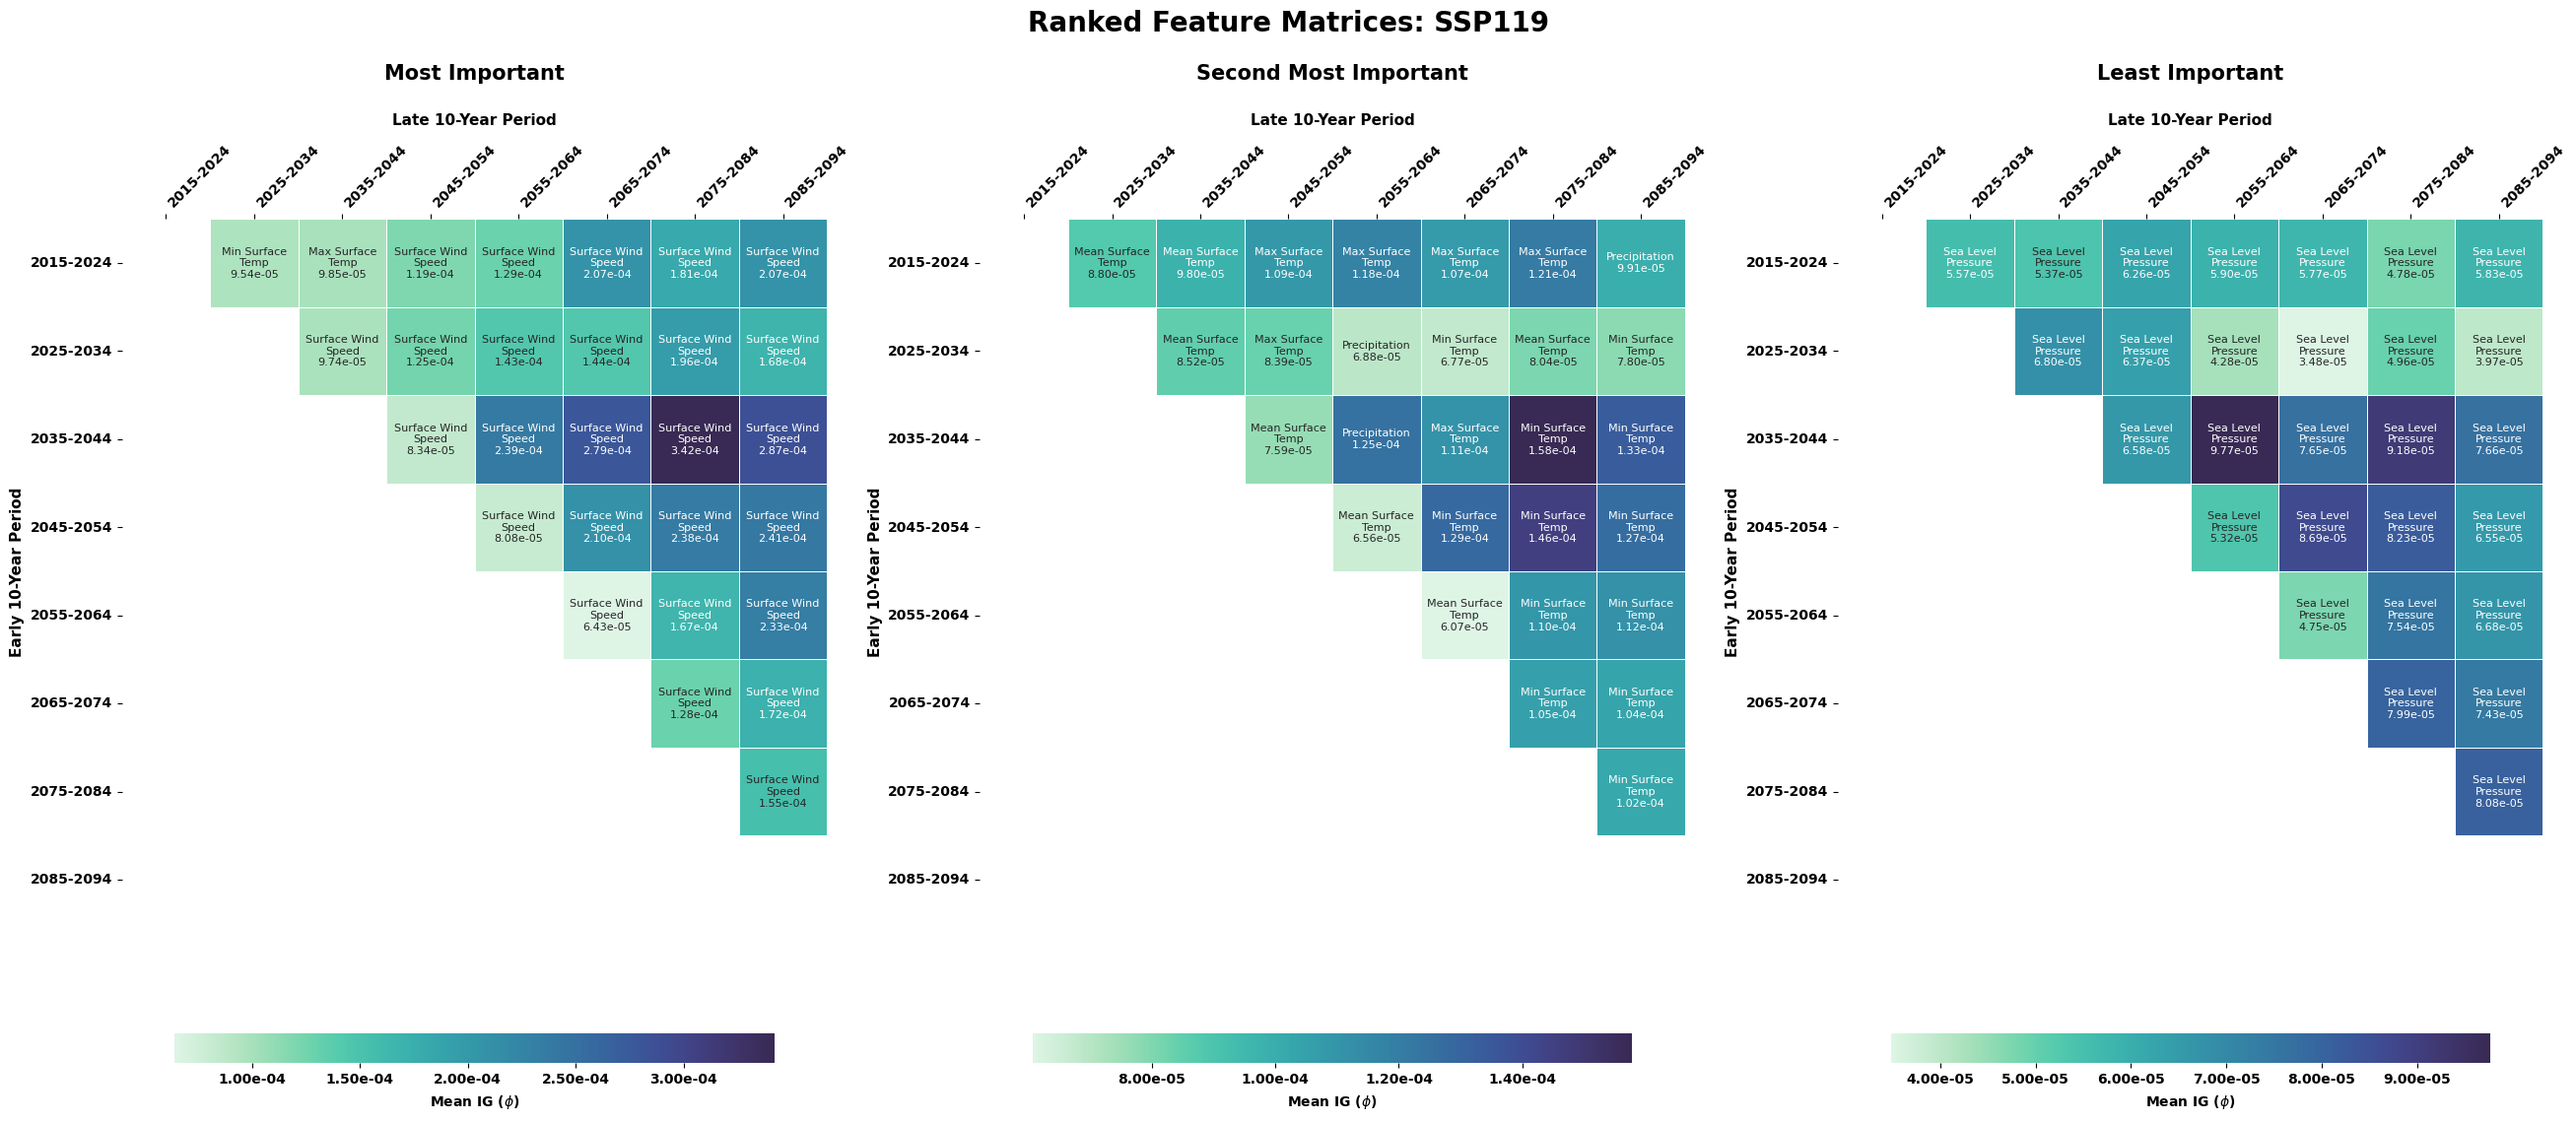

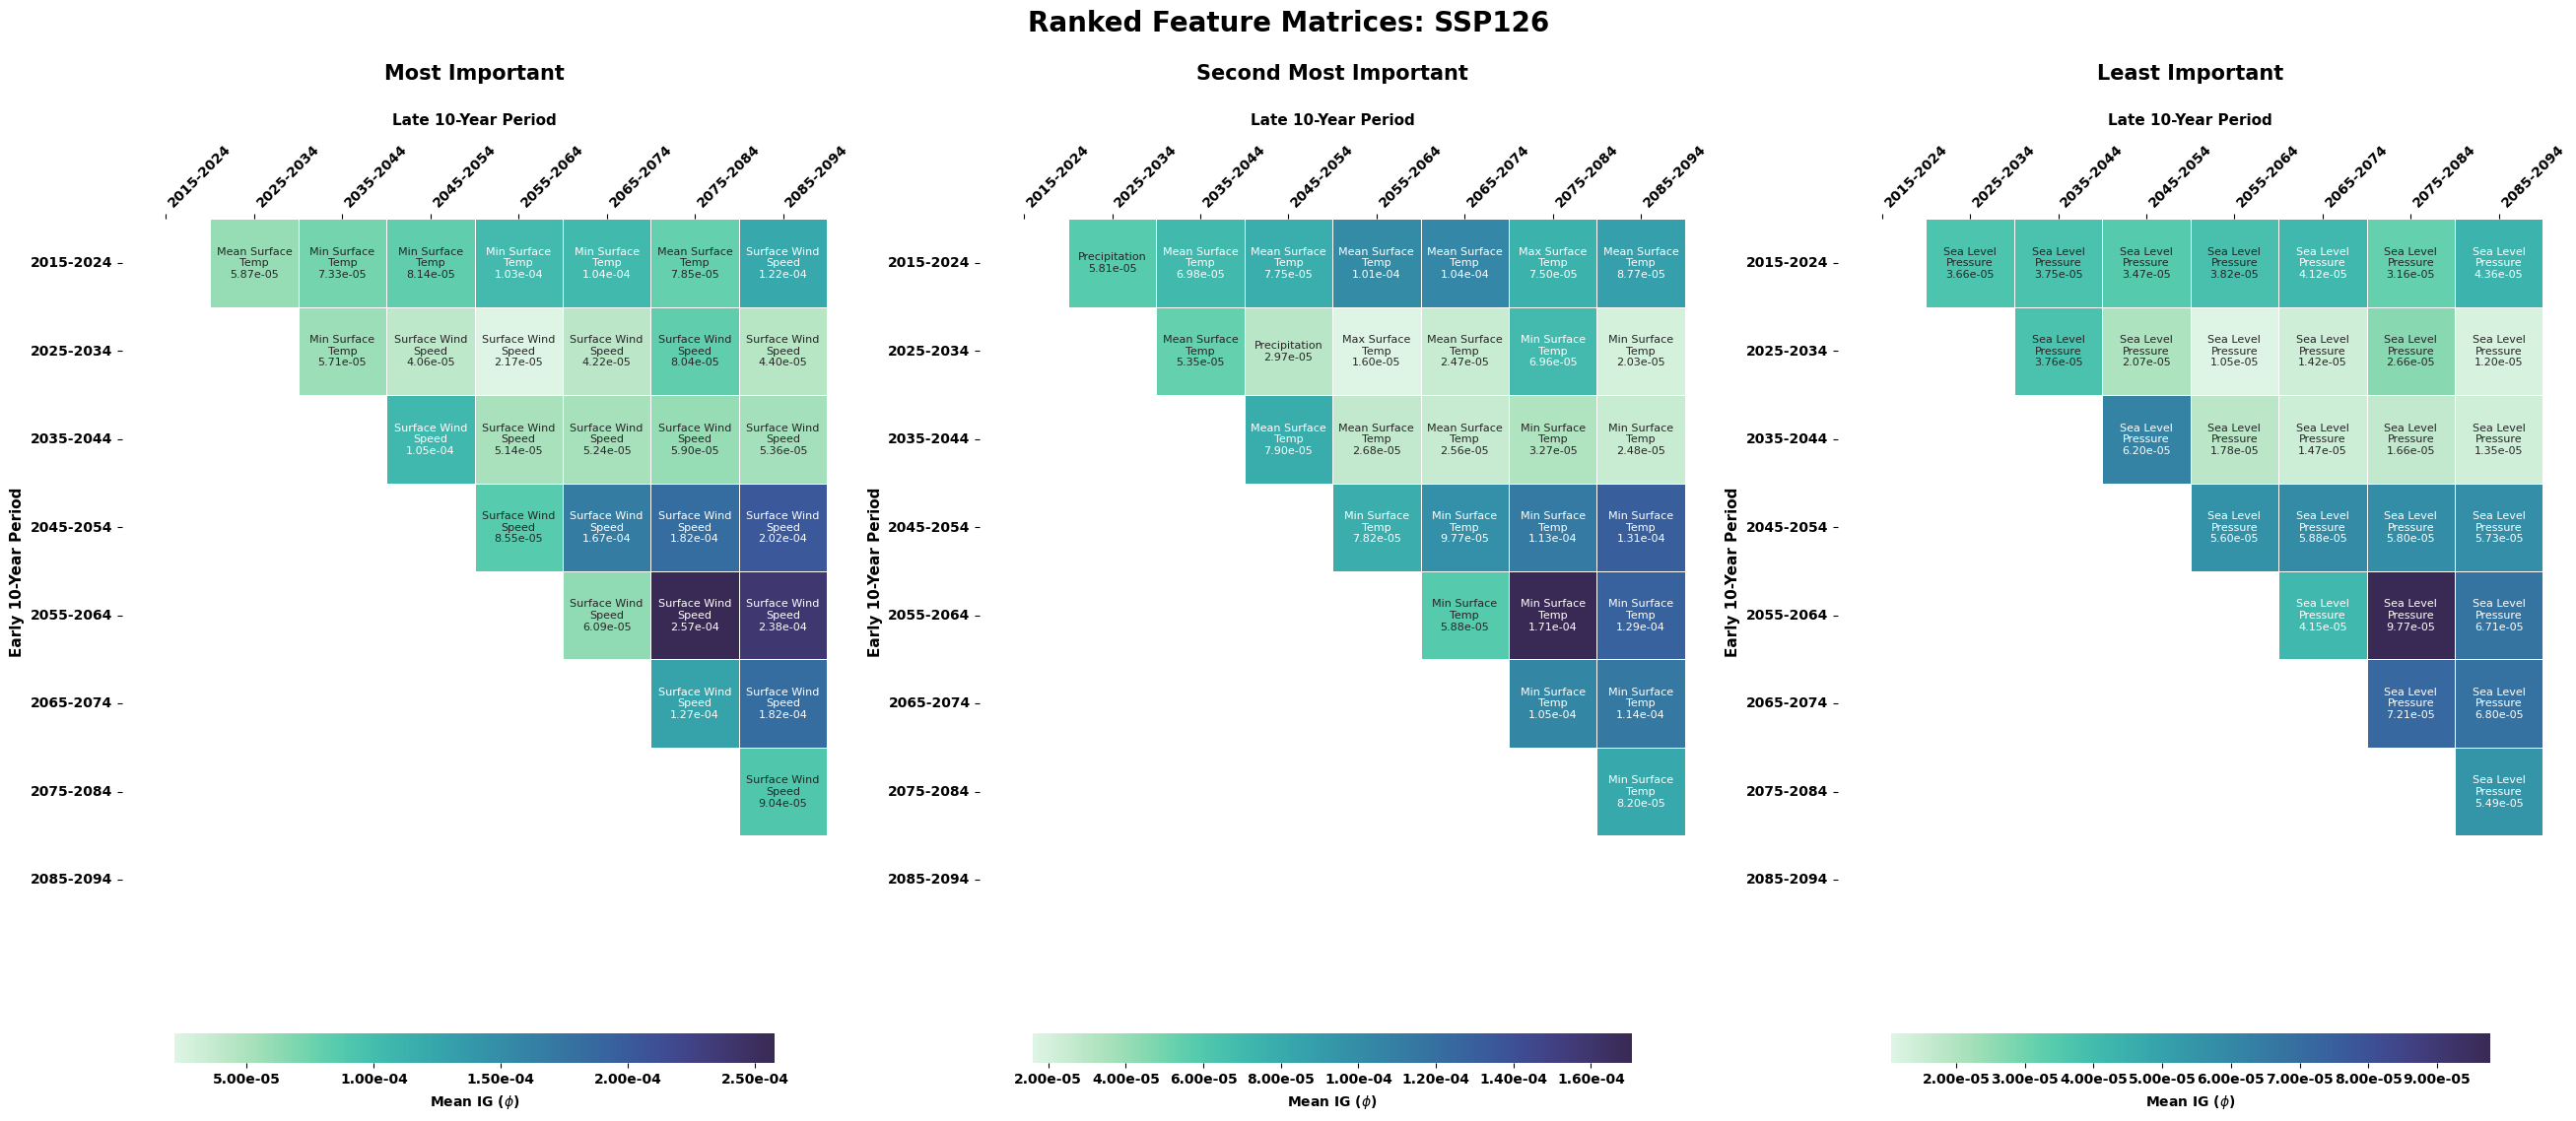

In [20]:
plot_var_imp(abs_val_phi_matrix, var_importance_heatmaps_three_colorbar)

#### **bar plot to show variable importance for specific yr combo and scenario**

In [21]:
def plot_single_combo_bar(phi_matrix, metadata_df, early_year, late_year, var_names, scenario_id="ssp119", _caller_name=None):
    """
    phi_matrix: all the averaged heatmaps from the ig layer of nc files --> shape = (10, 56, 144, 73, 6)
    metadata_df: df of all the unique yr combos
    var_names: variable names 
    scenario_id: scenario
    """
    
    # look up exact row for requested yr combo in the metadata
    match = metadata_df[(metadata_df['early'] == early_year) & (metadata_df['late'] == late_year)]
    
    # error handling if looking up yr combo that doesn't exist
    if match.empty:
        raise ValueError(f"no combo found for early yr of {early_year} and late yr of {late_year}")
    
    # .iloc[0] gets the specific row and the combo idx gives integer index 
    combo_idx = match.iloc[0]['combo_idx']
    

    # slice phi_matrix for that certain yr combo 
    combo_data = phi_matrix[:, combo_idx, :, :, :] # --> [runs, lat, long, vars]
    

    # averaging across long and lat with absolute values so measuring magnitude of importance 
    spatial_means_per_run = np.nanmean((combo_data), axis=(1, 2))
    
    # convert to dataframe for plotting with col names as the variables 
    df_runs = pd.DataFrame(spatial_means_per_run, columns=var_names)
    # melting so df is two cols: one with climate variable and other with mean var importance
    df_melted = df_runs.melt(var_name='variable', value_name='avg importance')
    

    # grouping melted df by the variable and calculate mean of importances (across the runs) for that variable then sort it in descending order 
    mean_order = df_melted.groupby('variable')['avg importance'].mean().sort_values(ascending=False)
    # storing variable list in the descending order
    order = mean_order.index
    
    # PLOTTING BAR PLOT
    plt.figure(figsize=(12, 7))
    
    # Assign the `x` variable to `hue` and set `legend=False` for the same effect.

    ax = sns.barplot(
        data=df_melted,
        x='variable',
        y='avg importance',
        legend=False,
        order=order,
        palette='mako',
        hue='variable',
        errorbar=None  # no standard deviation error bars
    )
    
    # finding lowest and highest variable importance bars or setting to 0 for abs val plots
    if bool(_caller_name and 'abs_val' in _caller_name):
        min_val = 0.0
    else:
        min_val = mean_order.min()
    max_val = mean_order.max() 

    # buffer based on range of max and min vals 
    y_range = max_val - min_val
    buffer = y_range * 0.02
    
    # loop thru the sorted descending variable list 
    for i, var in enumerate(order):
        val = mean_order[var]
        
        # POSITIVE BARS -- text above 
        if val >= 0:
            y_pos = val + buffer
            valign = 'bottom'
        # NEGATIVE BARS -- buffer above the 0 point on y axis 
        else:
            y_pos = 0 +  buffer
            valign = 'bottom'
            
        ax.text(i, y_pos,
                f"{val:.2e}",
                ha='center', va=valign, fontweight='bold', fontsize=10)
    
    # formatting stuff 
    plt.title(f"Variable Importance ({early_year} vs {late_year}) - {scenario_id.upper()}", 
              fontsize=18, fontweight='bold', pad=25)
    plt.xlabel("Climate Variables", fontsize=13, fontweight='bold', labelpad=15)
    plt.ylabel("Mean Integrated Gradients ($\phi$)", fontsize=13, fontweight='bold', labelpad=15)
    
    plt.xticks(fontsize=12, fontweight='bold')
    

    ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2e')) # y axis as scientific notation 
    plt.yticks(fontsize=11, fontweight='bold')
    

    plt.ylim(min_val * 1.15, max_val * 1.15) # scale y axis max value based on the highest bar
    
    plt.show()

#### **bar plot of var importance for specific yr combo for both scenarios**


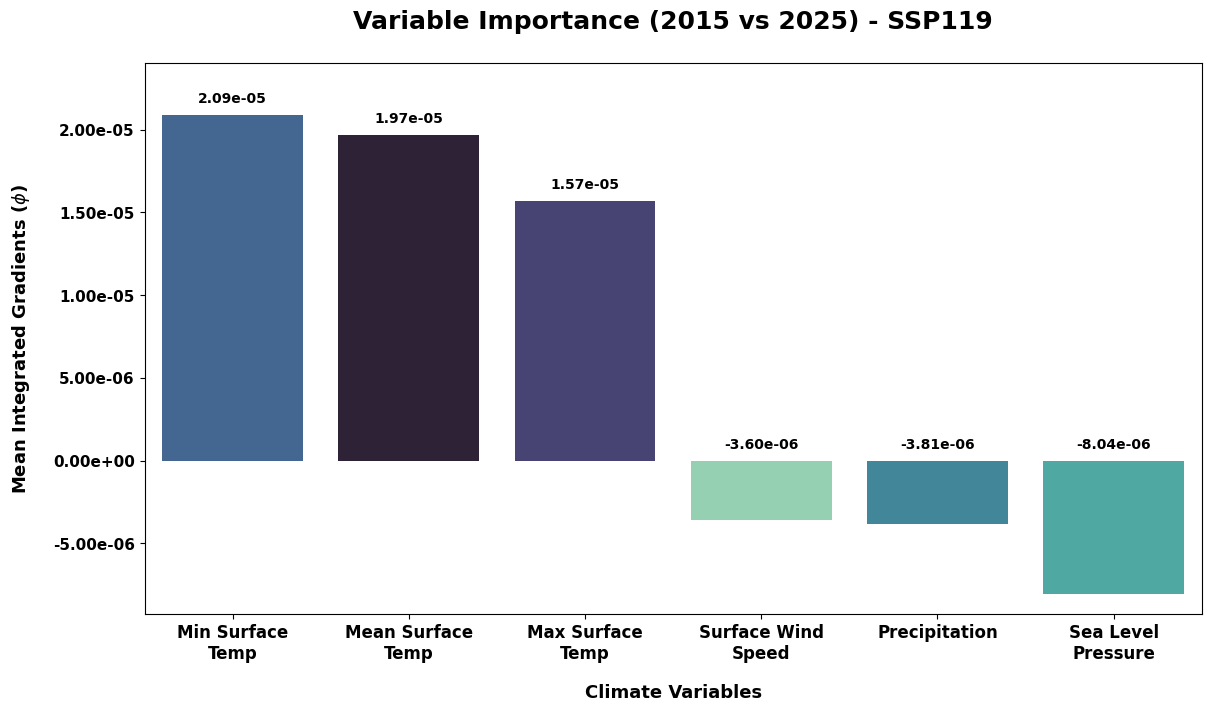

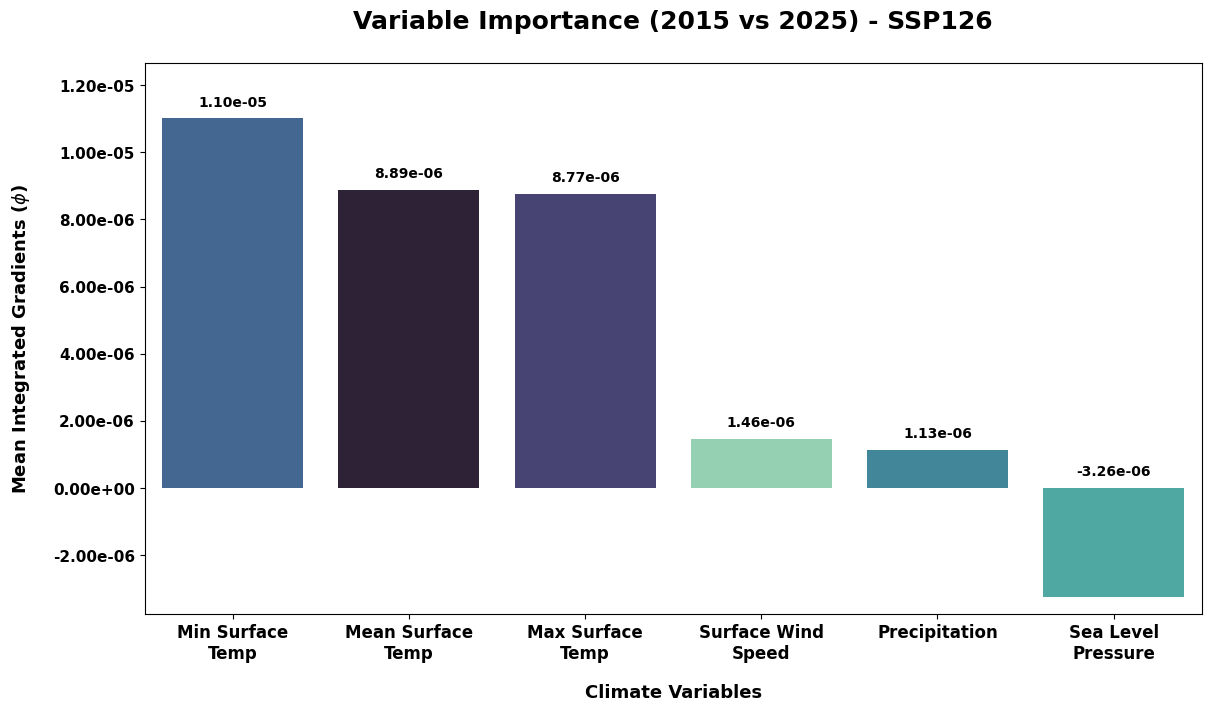

In [22]:
def plot_var_imp_bar(phi_matrix, early=2015, late=2025):

    # pulling unique scenario values
    unique_scenarios = metadata_df['scenario'].unique()

    for current_scenario in unique_scenarios:
        # filter metadata df for that one scenario 
        temp_df = metadata_df[metadata_df['scenario'] == current_scenario].copy()
        
        # slice phi matrix calculated above with the yr combo index values that are for that one scenario 
        temp_matrix = phi_matrix[:, temp_df['combo_idx'].values, :, :, :]
        
        # reset indices in df to match smaller matrix of the one scenario so only the early and late yrs are from that one scenario 
        temp_df['combo_idx'] = range(len(temp_df))
                

        # plot
        plot_single_combo_bar(
            phi_matrix=temp_matrix, 
            metadata_df=temp_df, 
            early_year=early,       
            late_year=late,         
            var_names=readable_variables, 
            scenario_id=current_scenario,
            _caller_name=argname('phi_matrix') # check if an abs_val matrix will be passed into plot_single_combo_bar
        )

plot_var_imp_bar(master_phi_matrix)

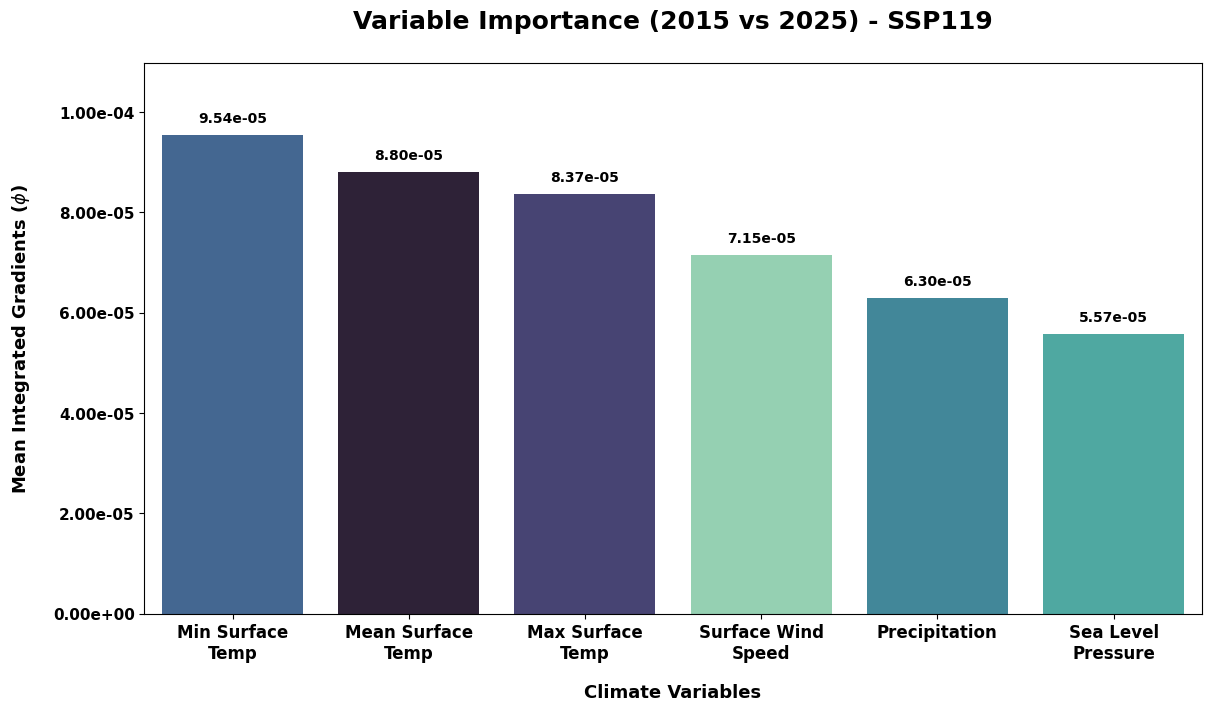

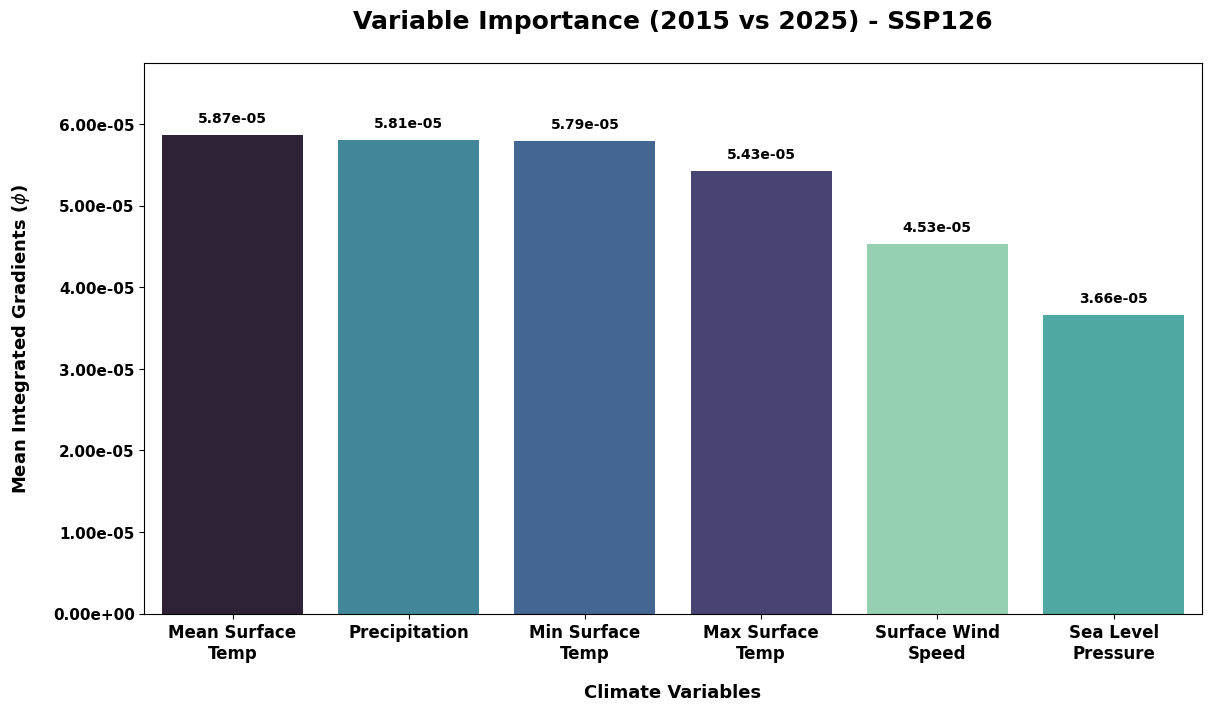

In [23]:
plot_var_imp_bar(abs_val_phi_matrix)

#### **plotting both regular and abs val bar plots in one plot**

In [59]:
def plot_both_bars(phi_matrix_1, phi_matrix_2, metadata_df, early_year, late_year, var_names, scenario_id="ssp119"):
    """
    phi_matrix_1: all the averaged heatmaps from the ig layer of nc files --> shape = (10, 56, 144, 73, 6) --> no abs val taken
    phi_matrix_2: same as above but abs val taken
    metadata_df: df of all the unique yr combos
    var_names: variable names 
    scenario_id: scenario
    """
    
    # look up exact row for requested yr combo in the metadata
    match = metadata_df[(metadata_df['early'] == early_year) & (metadata_df['late'] == late_year)]
    
    # error handling if looking up yr combo that doesn't exist
    if match.empty:
        raise ValueError(f"no combo found for early yr of {early_year} and late yr of {late_year}")
    
    # .iloc[0] gets the specific row and the combo idx gives integer index 
    combo_idx = match.iloc[0]['combo_idx']
    
    # Helper function to reduce repetition
    def make_vals(phi_matrix):

        # slice phi_matrix for that certain yr combo 
        combo_data = phi_matrix[:, combo_idx, :, :, :] # --> [runs, lat, long, vars]
    
        # averaging across long and lat with absolute values so measuring magnitude of importance 
        spatial_means_per_run = np.nanmean((combo_data), axis=(1, 2))
        
        # convert to dataframe for plotting with col names as the variables 
        df_runs = pd.DataFrame(spatial_means_per_run, columns=var_names)
        # melting so df is two cols: one with climate variable and other with mean var importance
        df_melted = df_runs.melt(var_name='Variable', value_name='Average Importance')
        

        # grouping melted df by the variable and calculate mean of importances (across the runs) for that variable then sort it in descending order 
        mean_order = df_melted.groupby('Variable')['Average Importance'].mean().sort_values(ascending=False)
        # storing variable list in the descending order
        order = mean_order.index

        return df_melted, mean_order, order
    
    df_melted_1, mean_order_1, order_1 = make_vals(phi_matrix_1)
    df_melted_2, mean_order_2, order_2 = make_vals(phi_matrix_2)

    df_melted_1['Absolute Value Taken'] = 'No'
    df_melted_2['Absolute Value Taken'] = 'Yes'
    
    df_combined = pd.concat([df_melted_1, df_melted_2], ignore_index=True)
    
    # Helper function to plot
    def plot_grouped_bar(df, order):

        fig, ax = plt.subplots(figsize=(10, 6))
        
        ax = sns.barplot(
            data=df,
            x='Variable',
            y='Average Importance',
            order=order,
            palette='mako',
            hue='Absolute Value Taken', # creating grouped bars
            errorbar=None  # no standard deviation error bars
        )

        return ax
    
    ax = plot_grouped_bar(df_combined, order_1) # could also be order_2, they are identical
    
    # finding lowest and highest variable importance bars 
    min_val = np.min(mean_order_1.min(), mean_order_2.min())
    max_val = np.max(mean_order_1.max(), mean_order_2.max())

    # buffer based on range of max and min vals 
    y_range = max_val - min_val
    buffer = y_range * 0.02
    
    # Last helper function
    def loop_vars(order, mean_order, ax):
        # loop thru the sorted descending variable list 
        for i, var in enumerate(order):
            val = mean_order[var]
            
            # POSITIVE BARS -- text above 
            if val >= 0:
                y_pos = val + buffer
                valign = 'bottom'
            # NEGATIVE BARS -- buffer above the 0 point on y axis 
            else:
                y_pos = 0 +  buffer
                valign = 'bottom'
                
            ax.text(i, y_pos,
                    f"{val:.2e}",
                    ha='center', va=valign, fontweight='bold', fontsize=10)
            
    loop_vars(order_1, mean_order_1, ax)
    loop_vars(order_2, mean_order_2, ax)

        
    # formatting stuff 
    plt.title(f"Variable Importance ({early_year} vs {late_year}) - {scenario_id.upper()}", 
              fontsize=18, fontweight='bold', pad=25)
    plt.xlabel("Climate Variables", fontsize=13, fontweight='bold', labelpad=15)
    plt.ylabel("Mean Integrated Gradients ($\phi$)", fontsize=13, fontweight='bold', labelpad=15)
    
    plt.xticks(fontsize=12, fontweight='bold')
    

    ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2e')) # y axis as scientific notation 
    plt.yticks(fontsize=11, fontweight='bold')
    

    plt.ylim(min_val * 1.15, max_val * 1.15) # scale y axis max value based on the highest bar
    
    plt.show()

TypeError: 'float' object cannot be interpreted as an integer

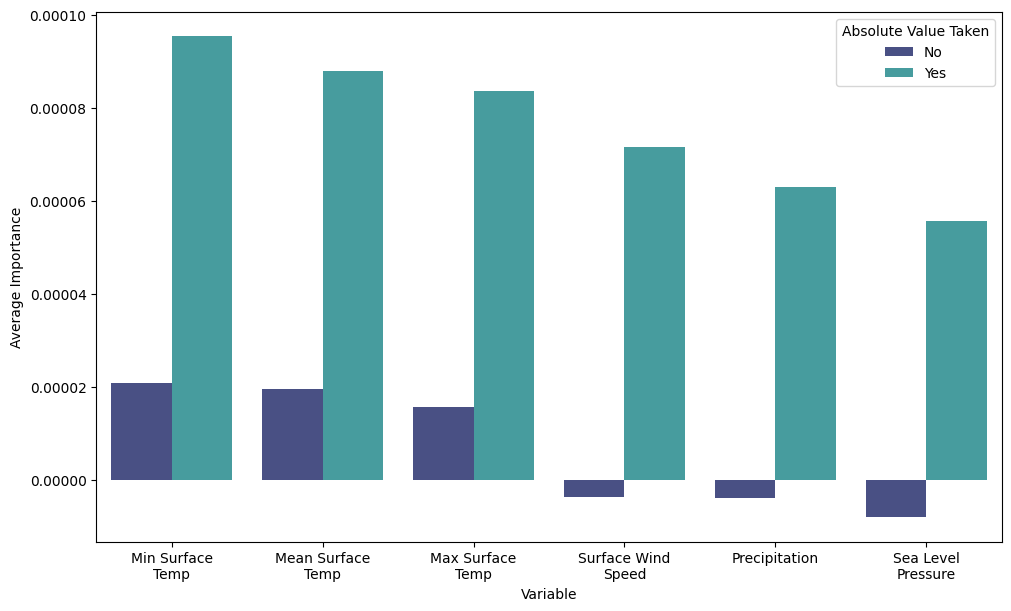

In [60]:
def plot_var_imp_both_bars(phi_matrix_1, phi_matrix_2, early=2015, late=2025):

    # pulling unique scenario values
    unique_scenarios = metadata_df['scenario'].unique()

    for current_scenario in unique_scenarios:
        # filter metadata df for that one scenario 
        temp_df = metadata_df[metadata_df['scenario'] == current_scenario].copy()
        
        # slice phi matrix calculated above with the yr combo index values that are for that one scenario 
        temp_matrix_1 = phi_matrix_1[:, temp_df['combo_idx'].values, :, :, :]

        temp_matrix_2 = phi_matrix_2[:, temp_df['combo_idx'].values, :, :, :]

        
        # reset indices in df to match smaller matrix of the one scenario so only the early and late yrs are from that one scenario 
        temp_df['combo_idx'] = range(len(temp_df))
                

        # plot
        plot_both_bars(
            phi_matrix_1=temp_matrix_1, 
            phi_matrix_2=temp_matrix_2,
            metadata_df=temp_df, 
            early_year=early,       
            late_year=late,         
            var_names=readable_variables, 
            scenario_id=current_scenario
            )

        

plot_var_imp_both_bars(master_phi_matrix, abs_val_phi_matrix)

### **supplementary figures**

for comparing total sum of importance values (not magnitude aka sum of phi) with attribution accuracy 

attribution accuracy = did XAI accurately capture what the model is trying to say? --> F(x) - F(x')


***need baseline prediction values for all the model runs***

##### **calculating prediction delta values**

*Local prediction method - will hold for every individual prediction*

In [ ]:
# initialize delta list 
delta_results = []

parent_dir = Path.cwd() / "climate_experiments" 

# for every result batch folder in climate_experiments
for run_folder in sorted(parent_dir.glob("result_batches*")):

    # list of .nc files
    nc_files = list(sorted(run_folder.glob("*.nc")))
    
    # for every nc file
    for file in nc_files:

        # open the file
        ds = xr.open_dataset(file)

        # extracting preds and baseline preds 
        y_preds = ds['y_pred'].values 
        baseline_preds = ds['exact_baseline_prediction'].values
        # getting difference between the two 
        pred_delta = y_preds - baseline_preds      
        
        # extracting early, late and scenario for better merging
        early = int(ds['early_yr'].values)
        late = int(ds['late_yr'].values)
        scenario = str(ds['scenario'].values)
        
        delta_results.append({
            'early': early,
            'late': late,
            'scenario': scenario,
            'pred_delta': pred_delta 
        })
        
        ds.close()

# make list into df 
deltas_df = pd.DataFrame(delta_results)

# merge left into metadata df on early/late/scenario
# metadata_df = pd.merge(metadata_df, deltas_df, on=['early', 'late', 'scenario'], how='left')

In [ ]:
deltas_df['pred_delta'][0]

array([ 0.56811005,  0.35843486,  0.61661845,  0.03162605,  0.51147014,
        0.6278849 ,  0.49335152,  0.62556744,  0.54979515,  0.5635731 ,
        0.52449554,  0.62176335, -0.28838548,  0.621567  ,  0.33590013,
        0.582458  ,  0.6162124 ,  0.57708794,  0.62755525,  0.62509084,
        0.59236896,  0.5416668 ,  0.59481645,  0.52513826,  0.6187804 ],
      dtype=float32)

In [ ]:
deltas_df

,early,late,scenario,pred_delta
0,2015,2025,ssp119,"[0.56811005, 0.35843486, 0.61661845, 0.0316260..."
1,2015,2035,ssp119,"[0.71374345, 0.63710296, 0.7137654, 0.71238756..."
2,2015,2045,ssp119,"[0.65113604, 0.065553606, 0.72106135, 0.669716..."
3,2015,2055,ssp119,"[0.60837954, 0.60608506, 0.60658, 0.6079873, 0..."
4,2015,2065,ssp119,"[0.6296356, 0.6234728, 0.62981486, 0.4992558, ..."
...,...,...,...,...
723,2055,2075,ssp126,"[0.6312176, 0.8427454, 0.8428205, 0.6125953, 0..."
724,2055,2085,ssp126,"[0.8498761, 0.87529695, 0.5424393, 0.870671, -..."
725,2065,2075,ssp126,"[0.7400931, 0.8915259, 0.46334368, 0.7785644, ..."
726,2065,2085,ssp126,"[0.4669899, 0.9285264, 0.34848267, 0.78630406,..."


In [ ]:
y_axis_completeness = np.array(deltas_df['pred_delta'])

In [ ]:
print(y_axis_completeness)

[array([ 0.56811005,  0.35843486,  0.61661845,  0.03162605,  0.51147014,
         0.6278849 ,  0.49335152,  0.62556744,  0.54979515,  0.5635731 ,
         0.52449554,  0.62176335, -0.28838548,  0.621567  ,  0.33590013,
         0.582458  ,  0.6162124 ,  0.57708794,  0.62755525,  0.62509084,
         0.59236896,  0.5416668 ,  0.59481645,  0.52513826,  0.6187804 ],
       dtype=float32)
 array([ 0.71374345,  0.63710296,  0.7137654 ,  0.71238756,  0.71310884,
         0.71288496,  0.70155984, -0.08745748,  0.704416  ,  0.6175875 ,
         0.7134261 ,  0.7133604 ,  0.6883732 ,  0.4210999 ,  0.682849  ,
         0.7126756 ,  0.60526717,  0.71244043,  0.65014017,  0.71271366,
         0.7130587 ,  0.6054185 ,  0.71360123,  0.71347064,  0.60187185],
       dtype=float32)
 array([0.65113604, 0.06555361, 0.72106135, 0.6697167 , 0.16630933,
        0.72105813, 0.71897864, 0.7209637 , 0.72106504, 0.7032728 ,
        0.7210653 , 0.71845686, 0.71887016, 0.71821153, 0.7191875 ,
        0.6976224 , 

In [ ]:
y_axis_completeness.shape

(728,)

#### *calcu

sum = 

##### **calculating sum of phis**

In [ ]:
# initialize delta list 
delta_results = []

parent_dir = Path.cwd() / "climate_experiments" 

# for every result batch folder in climate_experiments
for run_folder in sorted(parent_dir.glob("result_batches*")):

    # list of .nc files
    nc_files = list(sorted(run_folder.glob("*.nc")))
    
    # for every nc file
    for file in nc_files:

        # open the file
        ds = xr.open_dataset(file)

        # extracting preds and baseline preds 
        y_preds = ds['y_pred'].values 
        baseline_preds = ds['exact_baseline_prediction'].values
        # getting difference between the two 
        pred_delta = y_preds - baseline_preds      
        
        # extracting early, late and scenario for better merging
        early = int(ds['early_yr'].values)
        late = int(ds['late_yr'].values)
        scenario = str(ds['scenario'].values)
        
        delta_results.append({
            'early': early,
            'late': late,
            'scenario': scenario,
            'pred_delta': pred_delta 
        })
        
        ds.close()

# make list into df 
deltas_df = pd.DataFrame(delta_results)

In [ ]:

sorted_files = sorted(list(sample_folder.glob("*.nc")))

# initialize list 
phi_mapping = []

# calculating phi sum values 
# sum across globe and variables 
total_phi_sum = np.nansum(master_phi_matrix, axis=(2, 3, 4))
print(total_phi_sum)

# looping through sorted nc files to make sure everything aligned 
for i, filepath in enumerate(sorted_files):
    with xr.open_dataset(filepath) as ds:
        early = int(ds['early_yr'].values)
        late = int(ds['late_yr'].values)
        scenario = str(ds['scenario'].values) 
            
    # mapping the summed value to the scenario/yr combo 
    phi_mapping.append({
        'scenario': scenario,
        'early': early,
        'late': late,
        'completeness_sum': total_phi_sum[i] 
    })

# make into df 
phi_df = pd.DataFrame(phi_mapping)

# merge
metadata_df = pd.merge(
    metadata_df, 
    phi_df, 
    on=['scenario', 'early', 'late'], 
    how='left'
)

NameError: name 'sample_folder' is not defined

In [ ]:


def plot_combined_validation_matrices(df, scenario_id="ssp119"):
    """
    phi_matrix: all the averaged heatmaps from the ig layer of nc files --> shape = (10, 56, 144, 73, 6)
    metadata_df: df of all the unique yr combos
    scenario_id: scenario
    """
    
    # getting the unique yr combos
        # pulling out unique early yrs  and unique late yrs 
        # set with the | --> makes set with early and late yr combos and only the unique ones since set does not allow for duplicates
        # sorted --> keeps everything chrnological
    # all_years provides clean sorted integer list 
    all_years = sorted(list(set(df['early'].unique()) | set(df['late'].unique())))
    # list comprehension that gives nice formatting of starting yr and end yr for all yr values in all_years
    labels = [f"{int(y)}-{int(y)+9}" for y in all_years]
    
    # pivot table to rows as early yrs and cols are late yrs and phi sum is values 
    completeness_matrix = df.pivot_table(index='early', columns='late', values='completeness_sum', aggfunc='first')
    # reindexing to make matrix include every early and late yr combos
    completeness_matrix = completeness_matrix.reindex(index=all_years, columns=all_years)
    
    # pivot table to rows as early yrs and cols are late yrs and mean pred delta is values
    attribution_matrix = df.pivot_table(index='early', columns='late', values='mean_pred_delta', aggfunc='first')
    attribution_matrix = attribution_matrix.reindex(index=all_years, columns=all_years)
    
    # lower triangle mask
    mask = np.tril(np.ones_like(completeness_matrix, dtype=bool), k=0)

    
    # 1 row, 2 cols
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))
    
    # PHI SUM MATRIX 
    sns.heatmap(
        completeness_matrix,
        ax=ax1,
        mask=mask,
        cmap='BuGn', 
        annot=True,                  
        annot_kws={"size": 10, "fontweight": "bold"}, 
        fmt=".2e",                
        square=True,
        linewidths=.5,
        cbar_kws={"shrink": .8, "label": "Sum of $\phi$ (Net Prediction Delta)"} 
    )
    
    # phi sum colobar formaatting
    cbar1 = ax1.collections[0].colorbar
    cbar1.ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2e'))
    cbar1.ax.tick_params(labelsize=11)
    for tick in cbar1.ax.get_yticklabels():
        tick.set_fontweight('bold')
        
    # phi sum axes formatting
    ax1.xaxis.tick_top()
    ax1.xaxis.set_label_position('top')
    ax1.set_xticklabels(labels, rotation=45, ha='left', fontsize=11, fontweight='bold')
    ax1.set_yticklabels(labels, rotation=0, fontsize=11, fontweight='bold')
    ax1.set_xlabel("Late 10-Year Period", fontsize=13, fontweight='bold', labelpad=15)
    ax1.set_ylabel("Early 10-Year Period", fontsize=13, fontweight='bold')
    ax1.set_title(f"Completeness Validation Matrix: {scenario_id.upper()}", fontsize=18, fontweight='bold', pad=30)


    # MEAN DELTA PRED MATRIX
    sns.heatmap(
        attribution_matrix,
        ax=ax2,
        mask=mask,
        cmap='BuGn', 
        annot=True,                  
        annot_kws={"size": 10, "fontweight": "bold"}, 
        fmt=".2e",                 
        square=True,
        linewidths=.5,
        cbar_kws={"shrink": .8, "label": "Mean Prediction Delta: $F(x) - F(x')$"} 
    )
    
    # mean delta pred colorbar formatting
    cbar2 = ax2.collections[0].colorbar
    cbar2.ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2e'))
    cbar2.ax.tick_params(labelsize=11)
    for tick in cbar2.ax.get_yticklabels():
        tick.set_fontweight('bold')
        
    # mean delta pred axes formatting
    ax2.xaxis.tick_top()
    ax2.xaxis.set_label_position('top')
    ax2.set_xticklabels(labels, rotation=45, ha='left', fontsize=11, fontweight='bold')
    ax2.set_yticklabels(labels, rotation=0, fontsize=11, fontweight='bold')
    ax2.set_xlabel("Late 10-Year Period", fontsize=13, fontweight='bold', labelpad=15)
    ax2.set_ylabel("Early 10-Year Period", fontsize=13, fontweight='bold')
    ax2.set_title(f"Attribution Accuracy Matrix: {scenario_id.upper()}", fontsize=18, fontweight='bold', pad=30)
    
    plt.tight_layout()
    plt.show()

In [ ]:
unique_scenarios = metadata_df['scenario'].unique()

for current_scenario in unique_scenarios:
    # filter metadata df for that one scenario 
    temp_df = metadata_df[metadata_df['scenario'] == current_scenario].copy()
    
    # slice phi matrix calculated above with the yr combo index values that are for that one scenario 
    temp_matrix = master_phi_matrix[:, temp_df['combo_idx'].values, :, :, :]
    
    # reset indices in df to match smaller matrix of the one scenario so only the early and late yrs are from that one scenario 
    temp_df['combo_idx'] = range(len(temp_df))
    
    # plot
    plot_combined_validation_matrices(df=temp_df, 
        scenario_id=current_scenario 
    )

In [ ]:
metadata_df.columns

In [ ]:
metadata_df['ig_error']